# RASMapper Geometry Layer Updates


In [1]:
# PIP MODE: use the installed ras-commander package.
# Uncomment if needed in a clean environment:
# !pip install --upgrade ras-commander pywin32 psutil comtypes

import re
import shutil
import time
import zipfile
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ras_commander import M3Model, RasCmdr, RasExamples, RasMap, RasPlan, init_ras_project, ras
from ras_commander.gui import RasMapperLayerCommandWorkflow, RasMapperXsecUpdateWorkflow


## Developer Mode

When editing ras-commander locally, temporarily insert the repository root on `sys.path` before importing `ras_commander`:

```python
import sys
from pathlib import Path
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
```

Restore this notebook to pip mode before committing it.

# RASMapper Geometry Layer Updates

This notebook demonstrates the one-shot RASMapper geometry update workflows across several real model families: `Balde Eagle Creek`, `Muncie`, `BaldEagleCrkMulti2D`, `Davis`, `NewOrleansMetro`, and an HCFCD M3 model.

For validation, each enabled operation is isolated in its own project copy or extracted example project. The notebook clones the plan, updates the cloned plan description, short identifier, and plan title, points that cloned plan at the geometry being edited, enables the geometry preprocessor, runs the GUI update through `Ras.exe` and RASMapper, and then reruns the cloned plan with forced geometry preprocessing.

Each demonstration cell is followed by a validation cell. The validation cell reads the cloned plan, geometry artifacts, geometry HDF, and computed plan HDF back from disk and records whether the operation actually updated the model artifacts.

The committed notebook is dry-run by default. Set `RUN_GUI_UPDATES = True` only when you are ready for the notebook to drive the Windows desktop. Keep `COMPUTE_AFTER_GUI_UPDATE = True` when using this as the end-to-end validation notebook.


## Safety Switch

The update calls are intentionally stateful GUI automation. Keep `RUN_GUI_UPDATES = False` while reviewing the sequence. Flip it to `True` to execute the full cycle for each operation. When `COMPUTE_AFTER_GUI_UPDATE = True`, each successful GUI operation is followed by a forced recompute of that operation's cloned plan.


In [2]:
RUN_GUI_UPDATES = True
COMPUTE_AFTER_GUI_UPDATE = True
VERIFY_COMPUTE_MESSAGES = False
COMPUTE_NUM_CORES = 2
MAX_GUI_OPERATIONS = None
FORCE_CLOSE_RAS_BEFORE_EACH_OPERATION = True

PROJECT_SUFFIX = "123_rasmapper_updates"
RAS_VERSION = "7.0"
TIMEOUT_SECONDS = 900

# The notebook can run from the repo root or from examples/.
def find_repo_root():
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / "ras_commander").exists() and (candidate / "examples").exists():
            return candidate
    return Path.cwd()

REPO_ROOT = find_repo_root()
WORKING_ROOT = REPO_ROOT / "working" / "notebook_runs"
WORKING_ROOT.mkdir(parents=True, exist_ok=True)

print(f"RUN_GUI_UPDATES = {RUN_GUI_UPDATES}")
print(f"COMPUTE_AFTER_GUI_UPDATE = {COMPUTE_AFTER_GUI_UPDATE}")
print(f"Repo root: {REPO_ROOT}")
print(f"Working root: {WORKING_ROOT}")


RUN_GUI_UPDATES = True
COMPUTE_AFTER_GUI_UPDATE = True
Repo root: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928
Working root: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\working\notebook_runs


## Model And Operation Matrix

The matrix below uses multiple real projects so the notebook opens different model families while keeping one clear demonstration per geometry/update type. `BaldEagleCrkMulti2D` is used for several operations because its geometries intentionally vary by hydraulic element.


In [3]:
PROJECT_LIBRARY = {
    "balde_1d": {
        "label": "Balde Eagle Creek 1D",
        "source": "ras_examples",
        "project_name": "Balde Eagle Creek",
        "notes": "1D unsteady example with cross sections.",
    },
    "muncie": {
        "label": "Muncie",
        "source": "ras_examples",
        "project_name": "Muncie",
        "notes": "Mixed 1D/2D example with storage areas, lateral structures, edge lines, and blocked obstructions.",
    },
    "bald_multi2d": {
        "label": "BaldEagleCrkMulti2D",
        "source": "ras_examples",
        "project_name": "BaldEagleCrkMulti2D",
        "notes": "Multi-geometry 2D example with bridges, SA/2D connections, and different 2D layouts.",
    },
    "davis": {
        "label": "Davis",
        "source": "ras_examples",
        "project_name": "Davis",
        "notes": "Pipe/storm-system beta example that still exposes RASMapper geometry layers.",
    },
    "new_orleans": {
        "label": "NewOrleansMetro",
        "source": "ras_examples",
        "project_name": "NewOrleansMetro",
        "notes": "Special downloadable pipe/2D model; requires fallback project-file encoding support.",
    },
    "hcfcd_m3": {
        "label": "HCFCD M3 Clear Creek A120-00-00",
        "source": "m3_existing_or_download",
        "existing_project_path": REPO_ROOT / "examples" / "m3_models" / "Clear Creek" / "HEC-RAS" / "A120-00-00",
        "m3_model_id": "A",
        "m3_project_zip": "A120-00-00.zip",
        "m3_project_folder": "A120-00-00",
        "notes": "Real HCFCD M3 1D project used for blocked-obstruction validation examples.",
    },
}

DEMO_OPERATIONS = [
    {
        "demo_type": "1D cross sections",
        "label": "Balde Eagle Creek 1D: all XS attributes except terrain",
        "project_key": "balde_1d",
        "function": RasMapperXsecUpdateWorkflow.update_cross_sections,
        "args": ("01", "all_xs_attributes_except_terrain"),
        "geom_arg_index": 0,
        "plan_template": "01",
    },
    {
        "demo_type": "2D/pipe model cross sections",
        "label": "Davis pipe model: river stations table",
        "project_key": "davis",
        "function": RasMapperXsecUpdateWorkflow.update_cross_sections,
        "args": ("02", "river_stations_table"),
        "geom_arg_index": 0,
        "plan_template": "02",
    },
    {
        "demo_type": "Special pipe/2D model cross sections",
        "label": "New Orleans Metro: elevation profiles from terrain",
        "project_key": "new_orleans",
        "function": RasMapperXsecUpdateWorkflow.update_cross_sections,
        "args": ("02", "elevation_profiles_from_terrain"),
        "geom_arg_index": 0,
        "plan_template": "01",
    },
    {
        "demo_type": "XS interpolation surface",
        "label": "Muncie: compute XS interpolation surface",
        "project_key": "muncie",
        "function": RasMapperLayerCommandWorkflow.run_command,
        "args": ("Interpolation Surface", "xs_interpolation_surface", "04"),
        "geom_arg_index": 2,
        "plan_template": "04",
    },
    {
        "demo_type": "Storage area curves",
        "label": "Muncie: storage area elevation-volume curves",
        "project_key": "muncie",
        "function": RasMapperLayerCommandWorkflow.update_storage_area_curves,
        "args": ("01",),
        "geom_arg_index": 0,
        "plan_template": "01",
    },
    {
        "demo_type": "SA/2D connections",
        "label": "BaldEagle Multi2D: SA/2D connection from/to",
        "project_key": "bald_multi2d",
        "function": RasMapperLayerCommandWorkflow.update_sa2d_connections,
        "args": ("12", "connection_from_to"),
        "geom_arg_index": 0,
        "plan_template": "19",
    },
    {
        "demo_type": "Bridge/culvert properties",
        "label": "BaldEagle Multi2D: bridge/culvert river stations",
        "project_key": "bald_multi2d",
        "function": RasMapperLayerCommandWorkflow.update_structure,
        "args": ("03", "bridges_culverts", "river_stations"),
        "geom_arg_index": 0,
        "plan_template": "05",
    },
    {
        "demo_type": "Bridge/culvert terrain profiles",
        "label": "BaldEagle Multi2D: bridge/culvert terrain profiles",
        "project_key": "bald_multi2d",
        "function": RasMapperLayerCommandWorkflow.update_structure,
        "args": ("03", "bridges_culverts", "terrain"),
        "geom_arg_index": 0,
        "plan_template": "05",
    },
    {
        "demo_type": "Lateral structures",
        "label": "Muncie: lateral structure river stations",
        "project_key": "muncie",
        "function": RasMapperLayerCommandWorkflow.update_structure,
        "args": ("01", "lateral", "river_stations"),
        "geom_arg_index": 0,
        "plan_template": "01",
    },
    {
        "demo_type": "Edge lines",
        "label": "Muncie: create edge lines at XS limits",
        "project_key": "muncie",
        "function": RasMapperLayerCommandWorkflow.run_command,
        "args": ("Edge Lines", "edge_lines_compute", "01"),
        "geom_arg_index": 2,
        "plan_template": "01",
    },
    {
        "demo_type": "Blocked obstructions",
        "label": "HCFCD M3 Clear Creek: update blocked obstructions on XSs",
        "project_key": "hcfcd_m3",
        "function": RasMapperLayerCommandWorkflow.run_command,
        "args": ("Blocked Obstructions", "blocked_obstructions_update_on_xss", "01"),
        "geom_arg_index": 2,
        "plan_template": "02",
        "compute_after": False,
    },
    {
        "demo_type": "Blocked obstruction polygons",
        "label": "Muncie: create blocked-obstruction polygons from XS data",
        "project_key": "muncie",
        "function": RasMapperLayerCommandWorkflow.run_command,
        "args": ("Blocked Obstructions", "blocked_obstructions_create_polygons_from_xs", "01"),
        "geom_arg_index": 2,
        "plan_template": "01",
    },
]

model_summary = pd.DataFrame([
    {"key": key, "label": value["label"], "source": value["source"], "notes": value["notes"]}
    for key, value in PROJECT_LIBRARY.items()
])
operation_summary = pd.DataFrame([
    {
        "demo_type": op["demo_type"],
        "label": op["label"],
        "model": PROJECT_LIBRARY[op["project_key"]]["label"],
        "geometry": op["args"][op["geom_arg_index"]],
        "plan_template": op["plan_template"],
        "function": getattr(op["function"], "__qualname__", str(op["function"])),
    }
    for op in DEMO_OPERATIONS
])

display(model_summary)
display(operation_summary)


,key,label,source,notes
0,balde_1d,Balde Eagle Creek 1D,ras_examples,1D unsteady example with cross sections.
1,muncie,Muncie,ras_examples,"Mixed 1D/2D example with storage areas, latera..."
2,bald_multi2d,BaldEagleCrkMulti2D,ras_examples,"Multi-geometry 2D example with bridges, SA/2D ..."
3,davis,Davis,ras_examples,Pipe/storm-system beta example that still expo...
4,new_orleans,NewOrleansMetro,ras_examples,Special downloadable pipe/2D model; requires f...
5,hcfcd_m3,HCFCD M3 Clear Creek A120-00-00,m3_existing_or_download,Real HCFCD M3 1D project used for blocked-obst...


,demo_type,label,model,geometry,plan_template,function
0,1D cross sections,Balde Eagle Creek 1D: all XS attributes except...,Balde Eagle Creek 1D,01,01,RasMapperXsecUpdateWorkflow.update_cross_sections
1,2D/pipe model cross sections,Davis pipe model: river stations table,Davis,02,02,RasMapperXsecUpdateWorkflow.update_cross_sections
2,Special pipe/2D model cross sections,New Orleans Metro: elevation profiles from ter...,NewOrleansMetro,02,01,RasMapperXsecUpdateWorkflow.update_cross_sections
3,XS interpolation surface,Muncie: compute XS interpolation surface,Muncie,04,04,RasMapperLayerCommandWorkflow.run_command
4,Storage area curves,Muncie: storage area elevation-volume curves,Muncie,01,01,RasMapperLayerCommandWorkflow.update_storage_a...
5,SA/2D connections,BaldEagle Multi2D: SA/2D connection from/to,BaldEagleCrkMulti2D,12,19,RasMapperLayerCommandWorkflow.update_sa2d_conn...
6,Bridge/culvert properties,BaldEagle Multi2D: bridge/culvert river stations,BaldEagleCrkMulti2D,03,05,RasMapperLayerCommandWorkflow.update_structure
7,Bridge/culvert terrain profiles,BaldEagle Multi2D: bridge/culvert terrain prof...,BaldEagleCrkMulti2D,03,05,RasMapperLayerCommandWorkflow.update_structure
8,Lateral structures,Muncie: lateral structure river stations,Muncie,01,01,RasMapperLayerCommandWorkflow.update_structure
9,Edge lines,Muncie: create edge lines at XS limits,Muncie,01,01,RasMapperLayerCommandWorkflow.run_command


## Optional Individual Targets


In [4]:
INDIVIDUAL_STORAGE_AREA_NODE = None
INDIVIDUAL_SA2D_CONNECTION_NODE = None
INDIVIDUAL_BRIDGE_CULVERT_NODE = None
INDIVIDUAL_INLINE_STRUCTURE_NODE = None
INDIVIDUAL_LATERAL_STRUCTURE_NODE = None

print("Individual targets configured:")
for name, value in {
    "storage area": INDIVIDUAL_STORAGE_AREA_NODE,
    "SA/2D connection": INDIVIDUAL_SA2D_CONNECTION_NODE,
    "bridge/culvert": INDIVIDUAL_BRIDGE_CULVERT_NODE,
    "inline structure": INDIVIDUAL_INLINE_STRUCTURE_NODE,
    "lateral structure": INDIVIDUAL_LATERAL_STRUCTURE_NODE,
}.items():
    print(f"  {name}: {value}")


Individual targets configured:
  storage area: None
  SA/2D connection: None
  bridge/culvert: None
  inline structure: None
  lateral structure: None


## Execution Helper

`run_demo_operation()` is the test harness. For every enabled operation it prepares an isolated project copy, initializes HEC-RAS, clones the selected plan, updates the cloned plan metadata, enables geometry preprocessing, opens RASMapper through `Ras.exe`, performs one GUI operation, saves/exits, and optionally computes the cloned plan.

`validate_demo_operation()` reads the updated files back from disk. In live mode it confirms the plan metadata, geometry association, geometry HDF, result HDF, and file timestamps. Where HDF geometry/profile data are available, the validation cell also renders figures from the read-back artifacts.

In [5]:
operation_log = []


def operation_slug(label, ordinal):
    cleaned = re.sub(r"[^A-Za-z0-9]+", "_", label).strip("_").upper()
    cleaned = re.sub(r"_+", "_", cleaned)
    return f"RM{ordinal:02d}_{cleaned}"[:24]


def operation_title(label, ordinal):
    cleaned = re.sub(r"[^A-Za-z0-9 ]+", " ", label).strip()
    cleaned = re.sub(r"\s+", " ", cleaned)
    return f"RM {ordinal:02d} {cleaned}"[:32]


def read_text_with_fallback(path):
    for encoding in ("utf-8", "cp1252", "latin-1"):
        try:
            return Path(path).read_text(encoding=encoding), encoding
        except UnicodeDecodeError:
            continue
    return Path(path).read_text(encoding="latin-1", errors="replace"), "latin-1-replace"


def file_mtime(path):
    path = Path(path)
    return path.stat().st_mtime if path.exists() else None



def close_hecras_processes(reason="cleanup"):
    try:
        import psutil
    except Exception as exc:
        print(f"HEC-RAS cleanup skipped; psutil unavailable: {exc}")
        return 0

    targets = []
    for proc in psutil.process_iter(["pid", "name"]):
        name = (proc.info.get("name") or "").lower()
        if name in {"ras.exe", "rasmapper.exe"}:
            targets.append(proc)

    for proc in targets:
        try:
            proc.kill()
        except Exception:
            pass
    if targets:
        psutil.wait_procs(targets, timeout=5)
        print(f"Closed {len(targets)} HEC-RAS/RASMapper process(es) during {reason}.")
    return len(targets)


def hdf_probe(path):
    path = Path(path)
    probe = {
        "path": str(path),
        "exists": path.exists(),
        "readable": False,
        "root_keys": [],
        "has_geometry_group": False,
        "has_results_group": False,
        "error": None,
    }
    if not path.exists():
        return probe
    try:
        import h5py

        with h5py.File(path, "r") as hdf:
            probe["root_keys"] = list(hdf.keys())[:12]
            probe["has_geometry_group"] = "Geometry" in hdf
            probe["has_results_group"] = "Results" in hdf
            probe["readable"] = True
    except Exception as exc:
        probe["error"] = str(exc)
    return probe


GEOMETRY_LAYER_SPECS = [
    {
        "label": "2D cell centers",
        "group": "Geometry/2D Flow Areas",
        "points": "Cells Center Coordinate",
        "recursive": True,
        "kind": "scatter",
        "color": "#9ecae1",
        "alpha": 0.35,
        "size": 3,
    },
    {
        "label": "2D flow area perimeter",
        "group": "Geometry/2D Flow Areas",
        "points": "Polygon Points",
        "info": "Polygon Info",
        "kind": "polygon",
        "color": "#31a354",
        "linewidth": 1.4,
    },
    {
        "label": "Storage area perimeter",
        "group": "Geometry/Storage Areas",
        "points": "Polygon Points",
        "info": "Polygon Info",
        "kind": "polygon",
        "color": "#fd8d3c",
        "linewidth": 1.4,
    },
    {
        "label": "River centerline",
        "group": "Geometry/River Centerlines",
        "points": "Polyline Points",
        "info": "Polyline Info",
        "kind": "line",
        "color": "#08519c",
        "linewidth": 1.6,
    },
    {
        "label": "Cross sections",
        "group": "Geometry/Cross Sections",
        "points": "Polyline Points",
        "info": "Polyline Info",
        "kind": "line",
        "color": "#756bb1",
        "linewidth": 0.7,
    },
    {
        "label": "River bank lines",
        "group": "Geometry/River Bank Lines",
        "points": "Polyline Points",
        "info": "Polyline Info",
        "kind": "line",
        "color": "#238b45",
        "linewidth": 0.9,
    },
    {
        "label": "River edge lines",
        "group": "Geometry/River Edge Lines",
        "points": "Polyline Points",
        "info": "Polyline Info",
        "kind": "line",
        "color": "#41ab5d",
        "linewidth": 0.9,
    },
    {
        "label": "2D breaklines",
        "group": "Geometry/2D Flow Area Break Lines",
        "points": "Polyline Points",
        "info": "Polyline Info",
        "kind": "line",
        "color": "#de2d26",
        "linewidth": 1.1,
    },
    {
        "label": "Blocked obstructions",
        "group": "Geometry/Blocked Obstructions",
        "points": "Polygon Points",
        "info": "Polygon Info",
        "kind": "polygon",
        "color": "#636363",
        "linewidth": 1.1,
    },
    {
        "label": "Structures",
        "group": "Geometry/Structures",
        "points": "Centerline Points",
        "info": "Centerline Info",
        "kind": "line",
        "color": "#8c510a",
        "linewidth": 1.2,
    },
    {
        "label": "Gate openings",
        "group": "Geometry/Structures/Gate Groups/Openings",
        "points": "Centerline Points",
        "info": "Centerline Info",
        "kind": "line",
        "color": "#bf812d",
        "linewidth": 1.0,
    },
]


def decode_hdf_value(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace").strip("\x00 ")
    return str(value).strip("\x00 ")


def evenly_spaced_indices(length, count):
    if length <= 0:
        return []
    if length <= count:
        return list(range(length))
    return sorted(set(np.linspace(0, length - 1, count, dtype=int).tolist()))


def hdf_segments_from_info(points, info=None, max_segments=350):
    points = np.asarray(points)
    if points.ndim != 2 or points.shape[1] < 2 or len(points) == 0:
        return []
    xy = points[:, :2].astype(float, copy=False)

    if info is None:
        return [xy]

    segments = []
    info = np.asarray(info)
    for row in info[:max_segments]:
        if len(row) < 2:
            continue
        start = int(row[0])
        count = int(row[1])
        if start < 0 or count <= 0 or start >= len(xy):
            continue
        segment = xy[start : min(start + count, len(xy))]
        if len(segment) > 0:
            segments.append(segment)
    return segments


def sampled_xy(points, max_points=7000):
    points = np.asarray(points)
    if points.ndim != 2 or points.shape[1] < 2 or len(points) == 0:
        return np.empty((0, 2))
    xy = points[:, :2].astype(float, copy=False)
    if len(xy) > max_points:
        xy = xy[evenly_spaced_indices(len(xy), max_points)]
    return xy[np.isfinite(xy).all(axis=1)]


def iter_recursive_point_datasets(group, dataset_name):
    if dataset_name in group:
        yield group[dataset_name]
    for value in group.values():
        if hasattr(value, "keys"):
            yield from iter_recursive_point_datasets(value, dataset_name)


def plot_geometry_footprint(record):
    hdf_path = Path(record.get("geometry_hdf_path", ""))
    if not hdf_path.exists():
        return None

    import h5py

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    plotted_labels = set()
    plotted_count = 0

    with h5py.File(hdf_path, "r") as hdf:
        for spec in GEOMETRY_LAYER_SPECS:
            group = hdf.get(spec["group"])
            if group is None:
                continue

            if spec.get("recursive"):
                datasets = list(iter_recursive_point_datasets(group, spec["points"]))
                for dataset in datasets:
                    xy = sampled_xy(dataset[:])
                    if len(xy) == 0:
                        continue
                    label = spec["label"] if spec["label"] not in plotted_labels else "_nolegend_"
                    ax.scatter(
                        xy[:, 0],
                        xy[:, 1],
                        s=spec.get("size", 4),
                        c=spec.get("color", "#999999"),
                        alpha=spec.get("alpha", 0.4),
                        linewidths=0,
                        label=label,
                    )
                    plotted_labels.add(spec["label"])
                    plotted_count += 1
                continue

            if spec["points"] not in group:
                continue
            info = group[spec["info"]][:] if spec.get("info") and spec["info"] in group else None
            segments = hdf_segments_from_info(group[spec["points"]][:], info)
            for segment in segments:
                xy = sampled_xy(segment)
                if len(xy) == 0:
                    continue
                if spec.get("kind") == "polygon" and len(xy) > 2 and not np.allclose(xy[0], xy[-1]):
                    xy = np.vstack([xy, xy[0]])
                label = spec["label"] if spec["label"] not in plotted_labels else "_nolegend_"
                ax.plot(
                    xy[:, 0],
                    xy[:, 1],
                    color=spec.get("color", "#555555"),
                    linewidth=spec.get("linewidth", 1.0),
                    alpha=spec.get("alpha", 0.9),
                    label=label,
                )
                plotted_labels.add(spec["label"])
                plotted_count += 1

    if plotted_count == 0:
        plt.close(fig)
        return None

    ax.set_title(f"{record['project_label']} g{record['geometry_number']} geometry footprint")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, linewidth=0.4, alpha=0.35)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


def plot_artifact_timeline(record):
    phase_specs = [
        ("Before GUI", "pre_update_mtimes", "#9e9e9e", "o"),
        ("After GUI", "post_gui_mtimes", "#2b8cbe", "s"),
        ("After compute", "post_compute_mtimes", "#31a354", "^"),
    ]
    artifact_labels = {
        "plan_path": "Plan file",
        "plan_hdf_path": "Plan HDF",
        "geometry_path": "Geometry file",
        "geometry_hdf_path": "Geometry HDF",
        "geompre_path": "GeomPre file",
    }
    rows = []
    for phase, key, color, marker in phase_specs:
        for artifact, timestamp in (record.get(key) or {}).items():
            if timestamp is None:
                continue
            rows.append({
                "phase": phase,
                "artifact": artifact_labels.get(artifact, artifact),
                "timestamp": timestamp,
                "color": color,
                "marker": marker,
            })

    if not rows:
        return None

    frame = pd.DataFrame(rows)
    artifacts = list(dict.fromkeys(frame["artifact"].tolist()))
    y_positions = {artifact: i for i, artifact in enumerate(artifacts)}

    fig, ax = plt.subplots(figsize=(8.5, max(3.2, 0.45 * len(artifacts) + 1.5)))
    for phase, _, color, marker in phase_specs:
        subset = frame[frame["phase"] == phase]
        if subset.empty:
            continue
        ax.scatter(
            [datetime.fromtimestamp(value) for value in subset["timestamp"]],
            [y_positions[value] for value in subset["artifact"]],
            c=color,
            marker=marker,
            s=70,
            label=phase,
            zorder=3,
        )

    for event_key, label, color in [
        ("gui_started_at", "GUI start", "#08519c"),
        ("compute_started_at", "Compute start", "#238b45"),
    ]:
        timestamp = record.get(event_key)
        if timestamp:
            ax.axvline(datetime.fromtimestamp(timestamp), color=color, linestyle="--", linewidth=1.0, alpha=0.75)
            ax.text(
                datetime.fromtimestamp(timestamp),
                len(artifacts) - 0.55,
                label,
                rotation=90,
                va="top",
                ha="right",
                fontsize=8,
                color=color,
            )

    ax.set_yticks(range(len(artifacts)))
    ax.set_yticklabels(artifacts)
    ax.set_title(f"{record['project_label']} g{record['geometry_number']} artifact update times")
    ax.set_xlabel("File timestamp")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.grid(True, axis="x", linewidth=0.4, alpha=0.35)
    ax.legend(loc="best", fontsize=8)
    fig.autofmt_xdate(rotation=25)
    fig.tight_layout()
    return fig


def plot_storage_area_curves(hdf, record):
    info_path = "Geometry/Storage Areas/Volume Elevation Info"
    values_path = "Geometry/Storage Areas/Volume Elevation Values"
    if info_path not in hdf or values_path not in hdf:
        return None

    info = hdf[info_path][:]
    values = hdf[values_path][:]
    attrs = hdf.get("Geometry/Storage Areas/Attributes")
    names = []
    if attrs is not None and getattr(attrs.dtype, "names", None) and "Name" in attrs.dtype.names:
        names = [decode_hdf_value(row["Name"]) for row in attrs[:]]

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    plotted = 0
    for idx in evenly_spaced_indices(len(info), 5):
        start, count = int(info[idx][0]), int(info[idx][1])
        curve = values[start : start + count]
        if len(curve) == 0:
            continue
        label = names[idx] if idx < len(names) and names[idx] else f"Storage area {idx + 1}"
        ax.plot(curve[:, 0], curve[:, 1], marker="o", linewidth=1.1, markersize=3, label=label)
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        return None

    ax.set_title(f"{record['project_label']} g{record['geometry_number']} storage area curves")
    ax.set_xlabel("Volume")
    ax.set_ylabel("Elevation")
    ax.grid(True, linewidth=0.4, alpha=0.35)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


def plot_cross_section_profiles(hdf, record):
    info_path = "Geometry/Cross Sections/Station Elevation Info"
    values_path = "Geometry/Cross Sections/Station Elevation Values"
    if info_path not in hdf or values_path not in hdf:
        return None

    info = hdf[info_path][:]
    values = hdf[values_path][:]
    attrs = hdf.get("Geometry/Cross Sections/Attributes")
    labels = []
    if attrs is not None and getattr(attrs.dtype, "names", None):
        fields = attrs.dtype.names
        for row in attrs[:]:
            river = decode_hdf_value(row["River"]) if "River" in fields else ""
            reach = decode_hdf_value(row["Reach"]) if "Reach" in fields else ""
            rs = decode_hdf_value(row["RS"]) if "RS" in fields else ""
            labels.append(" ".join(part for part in [river, reach, rs] if part).strip())

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    plotted = 0
    for idx in evenly_spaced_indices(len(info), 5):
        start, count = int(info[idx][0]), int(info[idx][1])
        profile = values[start : start + count]
        profile = profile[np.isfinite(profile).all(axis=1)]
        if len(profile) == 0:
            continue
        label = labels[idx] if idx < len(labels) and labels[idx] else f"XS {idx + 1}"
        ax.plot(profile[:, 0], profile[:, 1], linewidth=1.1, label=label)
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        return None

    ax.set_title(f"{record['project_label']} g{record['geometry_number']} sample XS profiles")
    ax.set_xlabel("Station")
    ax.set_ylabel("Elevation")
    ax.grid(True, linewidth=0.4, alpha=0.35)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


def plot_xs_interpolation_surface(hdf, record):
    points_path = "Geometry/Cross Section Interpolation Surfaces/TIN Points"
    if points_path not in hdf:
        return None
    points = hdf[points_path][:]
    if points.ndim != 2 or points.shape[1] < 2 or len(points) == 0:
        return None

    sample = points[evenly_spaced_indices(len(points), min(len(points), 9000))]
    fig, ax = plt.subplots(figsize=(8.0, 5.5))
    color_values = sample[:, 2] if sample.shape[1] > 2 else None
    scatter = ax.scatter(sample[:, 0], sample[:, 1], c=color_values, s=4, cmap="viridis", linewidths=0, alpha=0.75)
    if color_values is not None:
        fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02, label="TIN point value")
    ax.set_title(f"{record['project_label']} g{record['geometry_number']} XS interpolation TIN points")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, linewidth=0.4, alpha=0.35)
    fig.tight_layout()
    return fig


def plot_profile_or_curve_samples(record):
    hdf_path = Path(record.get("geometry_hdf_path", ""))
    if not hdf_path.exists():
        return []

    import h5py

    figures = []
    demo_type = (record.get("demo_type") or "").lower()
    with h5py.File(hdf_path, "r") as hdf:
        if "storage" in demo_type:
            figure = plot_storage_area_curves(hdf, record)
            if figure is not None:
                figures.append(figure)
        if "interpolation" in demo_type:
            figure = plot_xs_interpolation_surface(hdf, record)
            if figure is not None:
                figures.append(figure)
        if "cross" in demo_type or "xsec" in demo_type or "1d" in demo_type:
            figure = plot_cross_section_profiles(hdf, record)
            if figure is not None:
                figures.append(figure)
    return figures


def display_validation_figures(record):
    figure_factories = [
        plot_artifact_timeline,
        plot_geometry_footprint,
    ]
    figures = []
    for factory in figure_factories:
        try:
            figure = factory(record)
        except Exception as exc:
            print(f"Figure skipped ({factory.__name__}): {exc}")
            figure = None
        if figure is not None:
            figures.append(figure)

    try:
        figures.extend(plot_profile_or_curve_samples(record))
    except Exception as exc:
        print(f"Figure skipped (profile/curve samples): {exc}")

    for figure in figures:
        display(figure)
        plt.close(figure)
    return len(figures)


def display_summary_figures(summary):
    if summary.empty:
        return 0

    figure_count = 0
    status_counts = summary["validation_status"].fillna("pending").value_counts(dropna=False)
    fig, ax = plt.subplots(figsize=(7.0, 3.8))
    colors = ["#31a354" if status == "passed" else "#9e9e9e" if status == "not_executed" else "#de2d26" for status in status_counts.index]
    ax.bar(status_counts.index.astype(str), status_counts.values, color=colors)
    ax.set_title("Validation status by demonstration")
    ax.set_xlabel("Validation status")
    ax.set_ylabel("Operation count")
    ax.grid(True, axis="y", linewidth=0.4, alpha=0.35)
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    figure_count += 1

    executed = summary[summary["executed"] == True]
    if not executed.empty:
        fig, ax = plt.subplots(figsize=(8.5, max(3.5, 0.42 * len(executed) + 1.5)))
        y = np.arange(len(executed))
        passed_flags = executed["validation_passed"].map(lambda value: bool(value) if pd.notna(value) else False)
        colors = ["#31a354" if value else "#de2d26" for value in passed_flags]
        ax.barh(y, [1] * len(executed), color=colors)
        ax.set_yticks(y)
        ax.set_yticklabels(executed["label"].str.slice(0, 60))
        ax.set_xlim(0, 1)
        ax.set_xticks([])
        ax.set_title("Executed demonstrations with validation outcome")
        ax.invert_yaxis()
        fig.tight_layout()
        display(fig)
        plt.close(fig)
        figure_count += 1

    return figure_count


def ensure_hcfcd_m3_project(project_config):
    existing = Path(project_config["existing_project_path"])
    if existing.exists():
        return existing

    model_path = M3Model.extract_model(
        project_config.get("m3_model_id", "A"),
        output_path=WORKING_ROOT / "m3_models",
    )
    ras_root = model_path / "HEC-RAS"
    project_folder = ras_root / project_config.get("m3_project_folder", "A120-00-00")
    if project_folder.exists():
        return project_folder

    zip_path = ras_root / project_config.get("m3_project_zip", "A120-00-00.zip")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(project_folder)
    return project_folder


def extract_operation_project(project_key, suffix):
    config = PROJECT_LIBRARY[project_key]
    source = config["source"]

    if source == "ras_examples":
        return RasExamples.extract_project(config["project_name"], suffix=suffix)

    if source == "m3_existing_or_download":
        source_path = ensure_hcfcd_m3_project(config)
        destination = WORKING_ROOT / "example_projects" / f"{source_path.name}_{suffix}"
        if destination.exists():
            shutil.rmtree(destination)
        shutil.copytree(source_path, destination)
        return destination

    raise ValueError(f"Unknown project source: {source}")


def resolve_plan_template(test_ras, requested_plan):
    if requested_plan is not None:
        requested = str(requested_plan).zfill(2)
        plan_path = test_ras.project_folder / f"{test_ras.project_name}.p{requested}"
        if plan_path.exists():
            return requested

    plan_numbers = sorted(str(value).zfill(2) for value in test_ras.plan_df["plan_number"].dropna())
    if not plan_numbers:
        raise ValueError(f"No plans found in {test_ras.project_folder}")
    return plan_numbers[0]


def artifact_paths(test_ras, plan_number, geom_number):
    project_folder = Path(test_ras.project_folder)
    project_name = test_ras.project_name
    return {
        "plan_path": project_folder / f"{project_name}.p{plan_number}",
        "plan_hdf_path": project_folder / f"{project_name}.p{plan_number}.hdf",
        "geometry_path": project_folder / f"{project_name}.g{geom_number}",
        "geometry_hdf_path": project_folder / f"{project_name}.g{geom_number}.hdf",
        "geompre_path": project_folder / f"{project_name}.c{geom_number}",
    }


def prepare_operation_plan(test_ras, plan_template, geometry_number, label, ordinal):
    plan_template = resolve_plan_template(test_ras, plan_template)
    shortid = operation_slug(label, ordinal)
    title = operation_title(label, ordinal)
    description = (
        f"RASMapper GUI validation operation {ordinal}: {label}. "
        f"Plan cloned from p{plan_template}; geometry g{geometry_number} is updated through Ras.exe/RASMapper. "
        "Geometry preprocessing is enabled and forced during compute."
    )
    cloned_plan = RasPlan.clone_plan(
        plan_template,
        new_plan_shortid=shortid,
        new_title=title,
        geometry=geometry_number,
        run_flags={"geometry_preprocessor": True},
        description=description,
        ras_object=test_ras,
    )

    # Re-apply the metadata explicitly so the validation cell documents the expected best practice.
    RasPlan.set_shortid(cloned_plan, shortid, ras_object=test_ras)
    RasPlan.set_plan_title(cloned_plan, title, ras_object=test_ras)
    RasPlan.update_plan_description(cloned_plan, description, ras_object=test_ras)
    RasPlan.update_run_flags(cloned_plan, geometry_preprocessor=True, ras_object=test_ras)

    return cloned_plan, shortid, title, description, plan_template


def run_or_show(
    label,
    fn,
    *args,
    enabled=True,
    skip_reason=None,
    project_key="muncie",
    plan_template=None,
    geom_arg_index=0,
    compute_after=None,
    **kwargs,
):
    ordinal = len(operation_log) + 1
    project_config = PROJECT_LIBRARY[project_key]
    operation_geom = str(args[geom_arg_index]).zfill(2) if geom_arg_index is not None else None
    shortid = operation_slug(label, ordinal)
    isolated_suffix = f"{PROJECT_SUFFIX}_{shortid.lower()}"
    run_args = list(args)
    if geom_arg_index is not None:
        run_args[geom_arg_index] = operation_geom
    if compute_after is None:
        compute_after = COMPUTE_AFTER_GUI_UPDATE

    record = {
        "label": label,
        "demo_type": None,
        "function": getattr(fn, "__qualname__", str(fn)),
        "project_key": project_key,
        "project_label": project_config["label"],
        "project_suffix": isolated_suffix,
        "geometry_number": operation_geom,
        "plan_template": plan_template,
        "plan_number": None,
        "plan_shortid": shortid,
        "args": tuple(run_args),
        "kwargs": kwargs,
        "enabled": enabled,
        "skip_reason": skip_reason,
        "executed": False,
        "success": None,
        "compute_after": compute_after,
        "compute_executed": False,
        "compute_success": None,
        "validation_status": None,
        "validation_passed": None,
        "validation_details": None,
        "error": None,
        "operation_started_at": None,
        "gui_started_at": None,
        "compute_started_at": None,
    }
    operation_log.append(record)

    print("-" * 80)
    print(label)
    print(f"Model: {project_config['label']} -> suffix {isolated_suffix}")
    print(f"Function: {record['function']}")
    print(f"Geometry: g{operation_geom}")
    print(f"Plan clone metadata: shortid={shortid}, title={operation_title(label, ordinal)}")
    print(f"Args: {tuple(run_args)}")
    print(f"Kwargs: {kwargs}")

    if not enabled:
        print(f"Skipped: {skip_reason or 'operation is disabled.'}")
        return None

    if RUN_GUI_UPDATES and MAX_GUI_OPERATIONS is not None and ordinal > MAX_GUI_OPERATIONS:
        record["enabled"] = False
        record["skip_reason"] = f"MAX_GUI_OPERATIONS is {MAX_GUI_OPERATIONS}"
        print(f"Skipped: MAX_GUI_OPERATIONS is {MAX_GUI_OPERATIONS}.")
        return None

    if not RUN_GUI_UPDATES:
        print("Dry run only. Set RUN_GUI_UPDATES = True to extract/copy an isolated project, clone the plan, run the GUI update, and compute the cloned plan.")
        return None

    try:
        if RUN_GUI_UPDATES and FORCE_CLOSE_RAS_BEFORE_EACH_OPERATION:
            close_hecras_processes("pre-operation cleanup")
        record["operation_started_at"] = time.time()
        test_project_path = extract_operation_project(project_key, isolated_suffix)
        test_ras = init_ras_project(test_project_path, RAS_VERSION)
        cloned_plan, plan_shortid, plan_title, plan_description, resolved_plan_template = prepare_operation_plan(
            test_ras,
            plan_template,
            operation_geom,
            label,
            ordinal,
        )
        paths = artifact_paths(test_ras, cloned_plan, operation_geom)
        record.update({
            "project_path": str(test_project_path),
            "project_name": test_ras.project_name,
            "plan_template": resolved_plan_template,
            "plan_number": cloned_plan,
            "plan_shortid": plan_shortid,
            "plan_title": plan_title,
            "plan_description": plan_description,
            **{key: str(value) for key, value in paths.items()},
            "pre_update_mtimes": {key: file_mtime(value) for key, value in paths.items()},
        })

        run_kwargs = dict(kwargs)
        run_kwargs["ras_object"] = test_ras
        record["gui_started_at"] = time.time()
        result = fn(*run_args, **run_kwargs)
        record["executed"] = True
        record["success"] = result.success
        record["post_gui_mtimes"] = {key: file_mtime(value) for key, value in paths.items()}
        if result.error:
            record["error"] = result.error
        print(f"GUI update success: {result.success}")
        if result.error:
            print(f"GUI update error: {result.error}")

        if result.success and compute_after:
            record["compute_started_at"] = time.time()
            compute_result = RasCmdr.compute_plan(
                cloned_plan,
                ras_object=test_ras,
                clear_geompre=True,
                force_geompre=True,
                force_rerun=True,
                num_cores=COMPUTE_NUM_CORES,
                verify=VERIFY_COMPUTE_MESSAGES,
            )
            record["compute_executed"] = True
            record["compute_success"] = bool(compute_result)
            record["post_compute_mtimes"] = {key: file_mtime(value) for key, value in paths.items()}
            print(f"Compute success: {bool(compute_result)}")
        return result
    except Exception as exc:
        record["error"] = str(exc)
        print(f"Operation failed: {exc}")
        raise
    finally:
        if RUN_GUI_UPDATES and FORCE_CLOSE_RAS_BEFORE_EACH_OPERATION:
            close_hecras_processes("post-operation cleanup")


def run_demo_operation(operation):
    before = len(operation_log)
    result = run_or_show(
        operation["label"],
        operation["function"],
        *operation["args"],
        enabled=operation.get("enabled", True),
        skip_reason=operation.get("skip_reason"),
        project_key=operation["project_key"],
        plan_template=operation.get("plan_template"),
        geom_arg_index=operation.get("geom_arg_index", 0),
        compute_after=operation.get("compute_after"),
        timeout=operation.get("timeout", TIMEOUT_SECONDS),
    )
    operation_log[before]["demo_type"] = operation["demo_type"]
    return result


def validate_demo_operation(operation_index):
    record = operation_log[operation_index]
    details = {
        "label": record["label"],
        "project": record["project_label"],
        "geometry_number": record["geometry_number"],
        "plan_number": record["plan_number"],
        "status": None,
        "passed": False,
    }

    if not record.get("executed"):
        details.update({
            "status": "not_executed",
            "reason": record.get("skip_reason") or "dry run or skipped before GUI execution",
        })
        record["validation_status"] = details["status"]
        record["validation_passed"] = None
        record["validation_details"] = details
        display(pd.DataFrame([details]))
        return details

    checks = {}
    started_at = (record.get("operation_started_at") or 0) - 2
    plan_path = Path(record["plan_path"])
    geometry_path = Path(record["geometry_path"])
    geometry_hdf_path = Path(record["geometry_hdf_path"])
    plan_hdf_path = Path(record["plan_hdf_path"])

    plan_text, plan_encoding = read_text_with_fallback(plan_path)
    checks["plan_file_read"] = plan_path.exists() and bool(plan_text)
    checks["plan_shortid_updated"] = f"Short Identifier={record['plan_shortid']}" in plan_text
    checks["plan_title_updated"] = f"Plan Title={record['plan_title']}" in plan_text
    checks["plan_geometry_updated"] = re.search(rf"^Geom File=\s*g?{record['geometry_number']}\s*$", plan_text, re.MULTILINE) is not None
    checks["geometry_preprocessor_enabled"] = re.search(r"^Run HTab=\s*-1\s*$", plan_text, re.MULTILINE) is not None

    geometry_text, geometry_encoding = read_text_with_fallback(geometry_path)
    checks["geometry_file_read"] = geometry_path.exists() and bool(geometry_text)
    checks["gui_update_succeeded"] = record.get("success") is True
    checks["geometry_artifact_updated"] = any(
        (mtime is not None and mtime >= started_at)
        for mtime in [file_mtime(geometry_path), file_mtime(geometry_hdf_path)]
    )

    geometry_hdf = hdf_probe(geometry_hdf_path)
    checks["geometry_hdf_read"] = geometry_hdf["readable"] and geometry_hdf["has_geometry_group"]

    if record.get("compute_after", COMPUTE_AFTER_GUI_UPDATE):
        result_hdf = hdf_probe(plan_hdf_path)
        checks["compute_ran"] = record.get("compute_executed") is True
        checks["compute_succeeded"] = record.get("compute_success") is True
        checks["result_hdf_read"] = result_hdf["readable"]
        checks["result_hdf_updated"] = (file_mtime(plan_hdf_path) or 0) >= started_at
    else:
        result_hdf = {"readable": None, "root_keys": []}
        checks["compute_skipped_by_operation"] = True

    passed = all(value is True for value in checks.values())
    details.update({
        "status": "passed" if passed else "failed",
        "passed": passed,
        "plan_path": str(plan_path),
        "plan_encoding": plan_encoding,
        "geometry_path": str(geometry_path),
        "geometry_encoding": geometry_encoding,
        "geometry_hdf_path": str(geometry_hdf_path),
        "geometry_hdf_keys": ", ".join(geometry_hdf["root_keys"]),
        "plan_hdf_path": str(plan_hdf_path),
        "plan_hdf_keys": ", ".join(result_hdf["root_keys"]),
        **checks,
    })
    record["validation_status"] = details["status"]
    record["validation_passed"] = details["passed"]
    record["validation_details"] = details
    display(pd.DataFrame([details]))
    figure_count = display_validation_figures(record)
    details["figures_displayed"] = figure_count
    record["validation_details"] = details
    if figure_count:
        print(f"Displayed {figure_count} validation figure(s).")
    return details


## Multi-Project Demonstrations And Validation

Each demonstration cell below is paired with a follow-up validation cell. In dry-run mode the validation cell records `not_executed`; in live mode it reads the updated artifacts and displays tables plus figures where the geometry/result files contain visualizable data.

### Demonstration 1: Balde Eagle Creek 1D: all XS attributes except terrain


In [6]:
run_demo_operation(DEMO_OPERATIONS[0])


2026-04-29 08:59:58 - ras_commander.RasExamples - INFO - Found zip file: C:\Users\billk_clb\AppData\Local\ras-commander\examples\Example_Projects_6_6.zip


2026-04-29 08:59:58 - ras_commander.RasExamples - INFO - Loading project data from CSV...


2026-04-29 08:59:58 - ras_commander.RasExamples - INFO - Loaded 68 projects from CSV.


2026-04-29 08:59:58 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 08:59:58 - ras_commander.RasExamples - INFO - Extracting project 'Balde Eagle Creek' as 'Balde Eagle Creek_122_rasmapper_updates_rm01_balde_eagle_creek_1'


...

2026-04-29 09:02:02 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Balde Eagle Creek_122_rasmapper_updates_rm01_balde_eagle_creek_1\BaldEagle.p03.hdf


2026-04-29 09:02:02 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Balde Eagle Creek_122_rasmapper_updates_rm01_balde_eagle_creek_1\BaldEagle.p03.hdf


2026-04-29 09:02:02 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Compute success: True
Closed 1 HEC-RAS/RASMapper process(es) during post-operation cleanup.


WorkflowResult(success=True, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper', 'Start geometry editing', 'Run layer command', 'Wait for command to complete', 'Save geometry'], steps_failed=[], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None, 'Start geometry editing': None, 'Run layer command': None, 'Wait for command to complete': None, 'Save geometry': None}, elapsed_seconds=30.189908981323242, error=None)

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,Balde Eagle Creek 1D: all XS attributes except...,Balde Eagle Creek 1D,01,03,passed,True,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,True,True,True,True,True,True,True


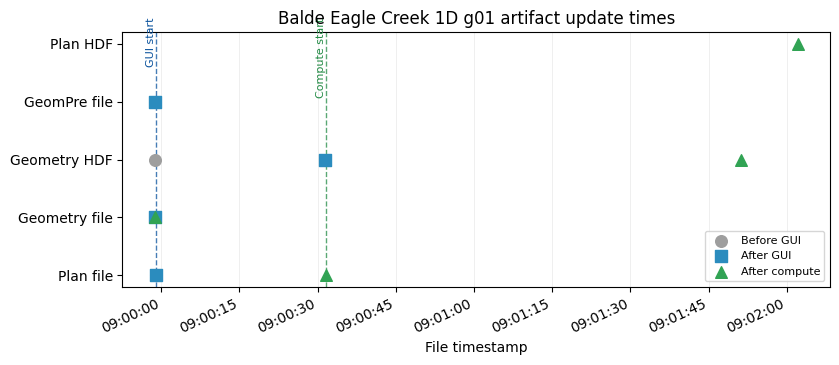

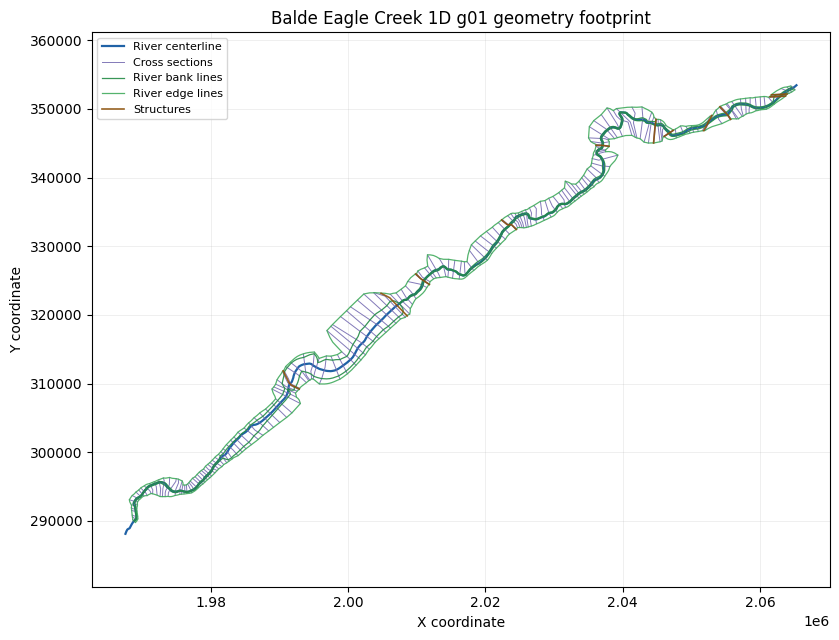

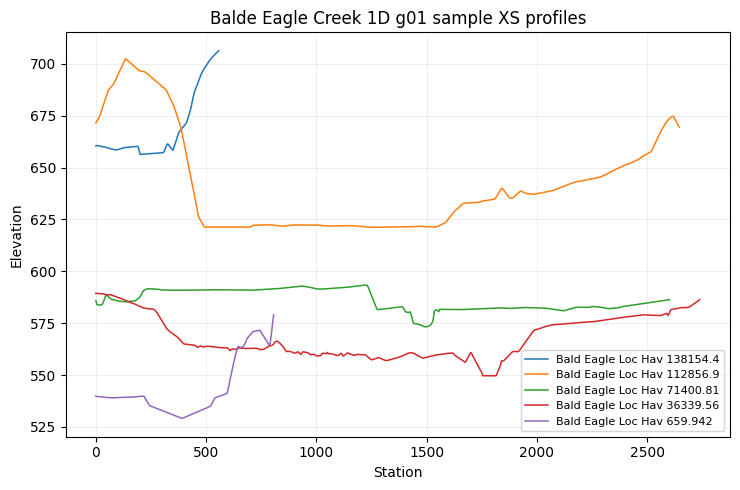

Displayed 3 validation figure(s).


{'label': 'Balde Eagle Creek 1D: all XS attributes except terrain',
 'project': 'Balde Eagle Creek 1D',
 'geometry_number': '01',
 'plan_number': '03',
 'status': 'passed',
 'passed': True,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Balde Eagle Creek_122_rasmapper_updates_rm01_balde_eagle_creek_1\\BaldEagle.p03',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Balde Eagle Creek_122_rasmapper_updates_rm01_balde_eagle_creek_1\\BaldEagle.g01',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Balde Eagle Creek_122_rasmapper_updates_rm01_balde_eagle_creek_1\\BaldEagle.g01.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Balde Ea

In [7]:
validate_demo_operation(0)


### Demonstration 2: Davis pipe model: river stations table


In [8]:
run_demo_operation(DEMO_OPERATIONS[1])


2026-04-29 09:02:03 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:02:03 - ras_commander.RasExamples - INFO - Extracting project 'Davis' as 'Davis_122_rasmapper_updates_rm02_davis_pipe_model_ri'


2026-04-29 09:02:03 - ras_commander.RasExamples - INFO - Successfully extracted project 'Davis' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Davis_122_rasmapper_updates_rm02_davis_pipe_model_ri


2026-04-29 09:02:03 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-04-29 09:02:03 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


...

2026-04-29 09:02:14 - ras_commander.gui.win32_primitives - INFO - Closed window: RAS Mapper


[!] Could not find 'Cross Sections' at depth 1


2026-04-29 09:02:19 - ras_commander.gui.win32_primitives - INFO - Closed window: HEC-RAS 7.0


GUI update success: False
GUI update error: Could not find RASMapper tree node: Davis Full System w_ Pump > Cross Sections


WorkflowResult(success=False, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper'], steps_failed=['Start geometry editing'], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None}, elapsed_seconds=10.503051280975342, error=RuntimeError('Could not find RASMapper tree node: Davis Full System w_ Pump > Cross Sections'))

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,Davis pipe model: river stations table,Davis,02,01,failed,False,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,False,True,True,False,False,False,False


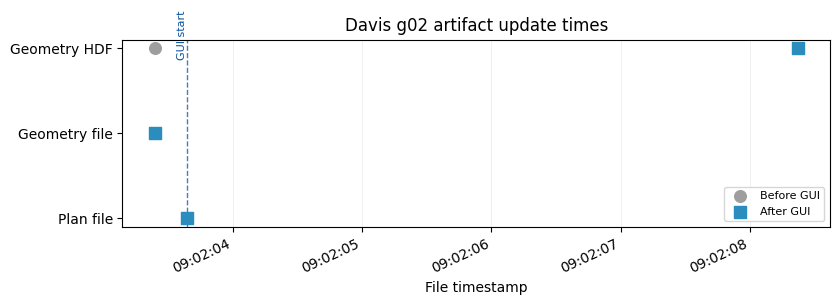

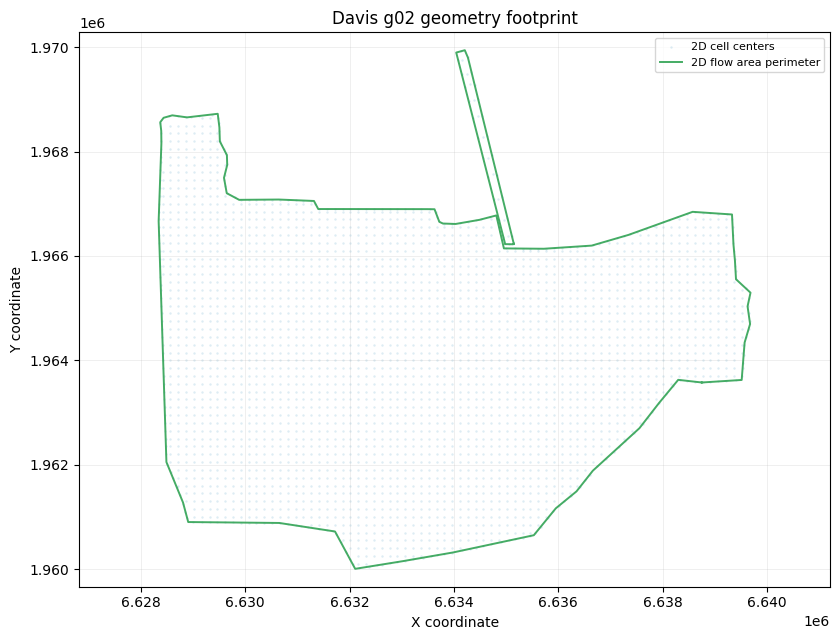

Displayed 2 validation figure(s).


{'label': 'Davis pipe model: river stations table',
 'project': 'Davis',
 'geometry_number': '02',
 'plan_number': '01',
 'status': 'failed',
 'passed': False,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Davis_122_rasmapper_updates_rm02_davis_pipe_model_ri\\DavisStormSystem.p01',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Davis_122_rasmapper_updates_rm02_davis_pipe_model_ri\\DavisStormSystem.g02',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Davis_122_rasmapper_updates_rm02_davis_pipe_model_ri\\DavisStormSystem.g02.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Davis_122_rasmapper_updates_rm02_davis_pipe_model_ri\

In [9]:
validate_demo_operation(1)


### Demonstration 3: New Orleans Metro: elevation profiles from terrain


In [10]:
run_demo_operation(DEMO_OPERATIONS[2])


2026-04-29 09:02:19 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Special Project -----


2026-04-29 09:02:19 - ras_commander.RasExamples - INFO - Extracting special project 'NewOrleansMetro' as 'NewOrleansMetro_122_rasmapper_updates_rm03_new_orleans_metro_e'


2026-04-29 09:02:19 - ras_commander.RasExamples - INFO - Downloading special project from: https://www.hec.usace.army.mil/confluence/rasdocs/hgt/files/latest/299502039/299502111/1/1747692522764/NewOrleansMetroPipesExample.zip


2026-04-29 09:02:19 - ras_commander.RasExamples - INFO - This may take a few moments...


--------------------------------------------------------------------------------
New Orleans Metro: elevation profiles from terrain
Model: NewOrleansMetro -> suffix 122_rasmapper_updates_rm03_new_orleans_metro_e
Function: RasMapperXsecUpdateWorkflow.update_cross_sections
Geometry: g02
Plan clone metadata: shortid=RM03_NEW_ORLEANS_METRO_E, title=RM 03 New Orleans Metro elevatio
Args: ('02', 'elevation_profiles_from_terrain')
Kwargs: {'timeout': 900}


...

2026-04-29 09:02:41 - ras_commander.gui.win32_primitives - INFO - Closed window: RAS Mapper


[!] Could not find 'Cross Sections' at depth 1


2026-04-29 09:02:46 - ras_commander.gui.win32_primitives - INFO - Closed window: HEC-RAS 7.0


GUI update success: False
GUI update error: Could not find RASMapper tree node: 2D Surface Model w Pipes > Cross Sections


WorkflowResult(success=False, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper'], steps_failed=['Start geometry editing'], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None}, elapsed_seconds=13.51828908920288, error=RuntimeError('Could not find RASMapper tree node: 2D Surface Model w Pipes > Cross Sections'))

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,New Orleans Metro: elevation profiles from ter...,NewOrleansMetro,02,02,failed,False,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,False,True,True,False,False,False,False


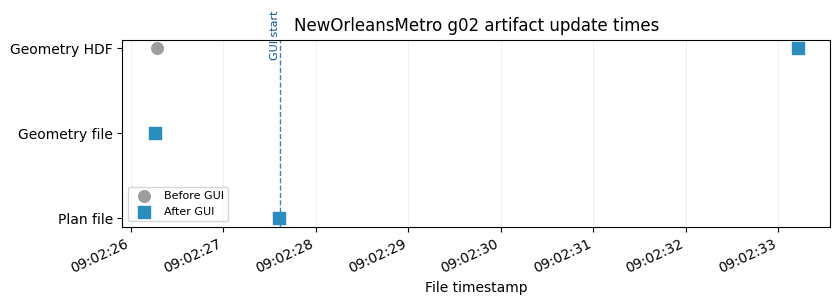

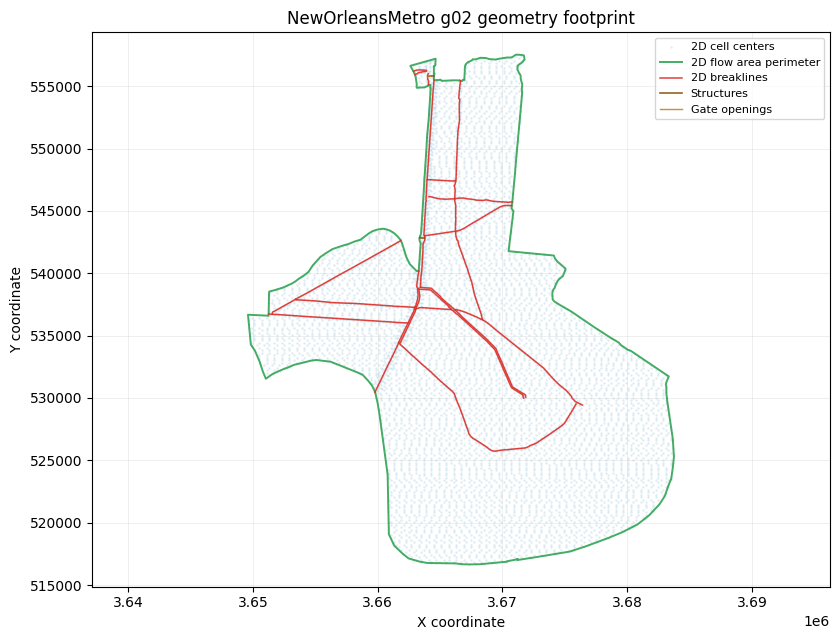

Displayed 2 validation figure(s).


{'label': 'New Orleans Metro: elevation profiles from terrain',
 'project': 'NewOrleansMetro',
 'geometry_number': '02',
 'plan_number': '02',
 'status': 'failed',
 'passed': False,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\NewOrleansMetro_122_rasmapper_updates_rm03_new_orleans_metro_e\\NewOrleansMetro.p02',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\NewOrleansMetro_122_rasmapper_updates_rm03_new_orleans_metro_e\\NewOrleansMetro.g02',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\NewOrleansMetro_122_rasmapper_updates_rm03_new_orleans_metro_e\\NewOrleansMetro.g02.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\NewO

In [11]:
validate_demo_operation(2)


### Demonstration 4: Muncie: compute XS interpolation surface


In [12]:
run_demo_operation(DEMO_OPERATIONS[3])


2026-04-29 09:02:46 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:02:46 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_122_rasmapper_updates_rm04_muncie_compute_xs_i'


--------------------------------------------------------------------------------
Muncie: compute XS interpolation surface
Model: Muncie -> suffix 122_rasmapper_updates_rm04_muncie_compute_xs_i
Function: RasMapperLayerCommandWorkflow.run_command
Geometry: g04
Plan clone metadata: shortid=RM04_MUNCIE_COMPUTE_XS_I, title=RM 04 Muncie compute XS interpol
Args: ('Interpolation Surface', 'xs_interpolation_surface', '04')
Kwargs: {'timeout': 900}


2026-04-29 09:02:46 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm04_muncie_compute_xs_i


2026-04-29 09:02:46 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


...

2026-04-29 09:03:53 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm04_muncie_compute_xs_i\Muncie.p02.hdf


2026-04-29 09:03:53 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm04_muncie_compute_xs_i\Muncie.p02.hdf


2026-04-29 09:03:53 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Compute success: True
Closed 1 HEC-RAS/RASMapper process(es) during post-operation cleanup.


WorkflowResult(success=True, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper', 'Start geometry editing', 'Run layer command', 'Wait for command to complete', 'Save geometry'], steps_failed=[], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None, 'Start geometry editing': None, 'Run layer command': None, 'Wait for command to complete': None, 'Save geometry': None}, elapsed_seconds=28.322401762008667, error=None)

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,Muncie: compute XS interpolation surface,Muncie,04,02,passed,True,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,True,True,True,True,True,True,True


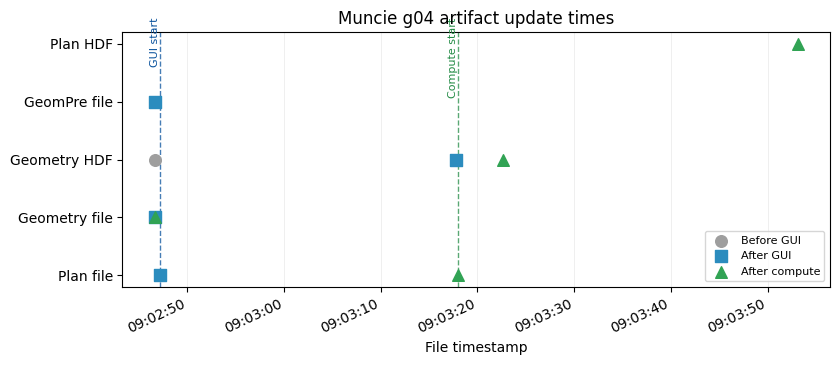

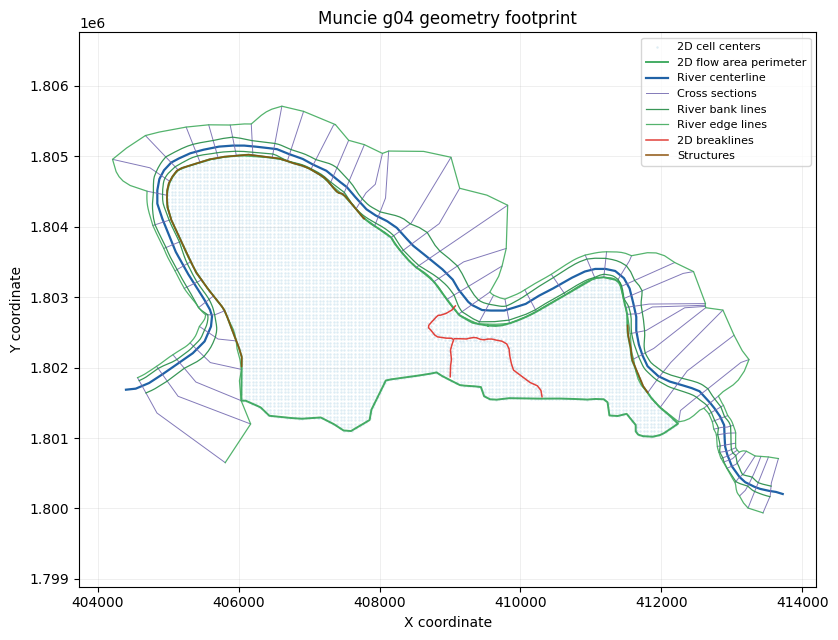

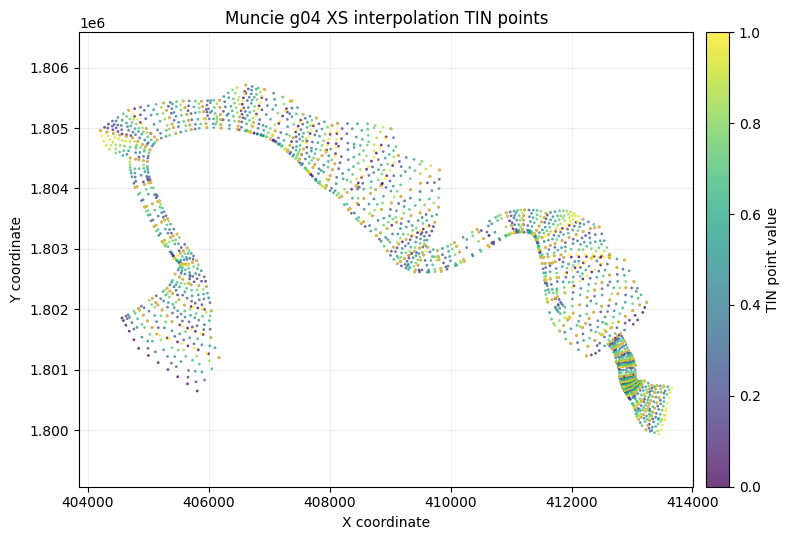

Displayed 3 validation figure(s).


{'label': 'Muncie: compute XS interpolation surface',
 'project': 'Muncie',
 'geometry_number': '04',
 'plan_number': '02',
 'status': 'passed',
 'passed': True,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm04_muncie_compute_xs_i\\Muncie.p02',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm04_muncie_compute_xs_i\\Muncie.g04',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm04_muncie_compute_xs_i\\Muncie.g04.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm04_muncie_compute_xs_i\\Muncie.p02.hdf',
 'plan

In [13]:
validate_demo_operation(3)


### Demonstration 5: Muncie: storage area elevation-volume curves


In [14]:
run_demo_operation(DEMO_OPERATIONS[4])


2026-04-29 09:03:54 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:03:54 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_122_rasmapper_updates_rm05_muncie_storage_area'


--------------------------------------------------------------------------------
Muncie: storage area elevation-volume curves
Model: Muncie -> suffix 122_rasmapper_updates_rm05_muncie_storage_area
Function: RasMapperLayerCommandWorkflow.update_storage_area_curves
Geometry: g01
Plan clone metadata: shortid=RM05_MUNCIE_STORAGE_AREA, title=RM 05 Muncie storage area elevat
Args: ('01',)
Kwargs: {'timeout': 900}


2026-04-29 09:03:54 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm05_muncie_storage_area


2026-04-29 09:03:54 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


...

2026-04-29 09:04:38 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm05_muncie_storage_area\Muncie.p02.hdf


2026-04-29 09:04:38 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm05_muncie_storage_area\Muncie.p02.hdf


2026-04-29 09:04:38 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Compute success: True


WorkflowResult(success=True, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper', 'Start geometry editing', 'Run layer command', 'Wait for command to complete', 'Save geometry'], steps_failed=[], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None, 'Start geometry editing': None, 'Run layer command': None, 'Wait for command to complete': None, 'Save geometry': None}, elapsed_seconds=27.785340309143066, error=None)

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,Muncie: storage area elevation-volume curves,Muncie,01,02,passed,True,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,True,True,True,True,True,True,True


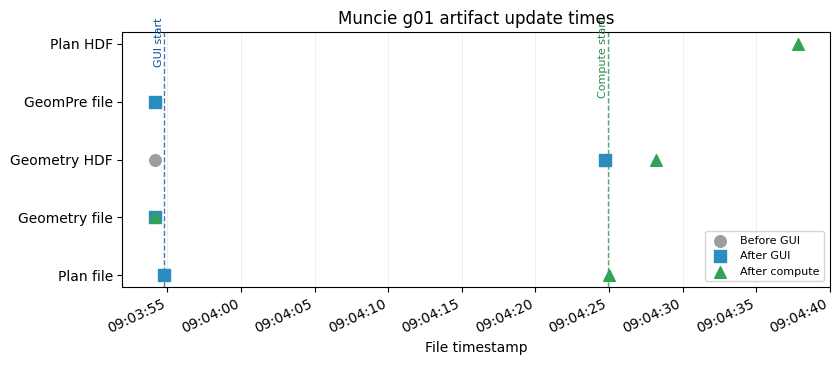

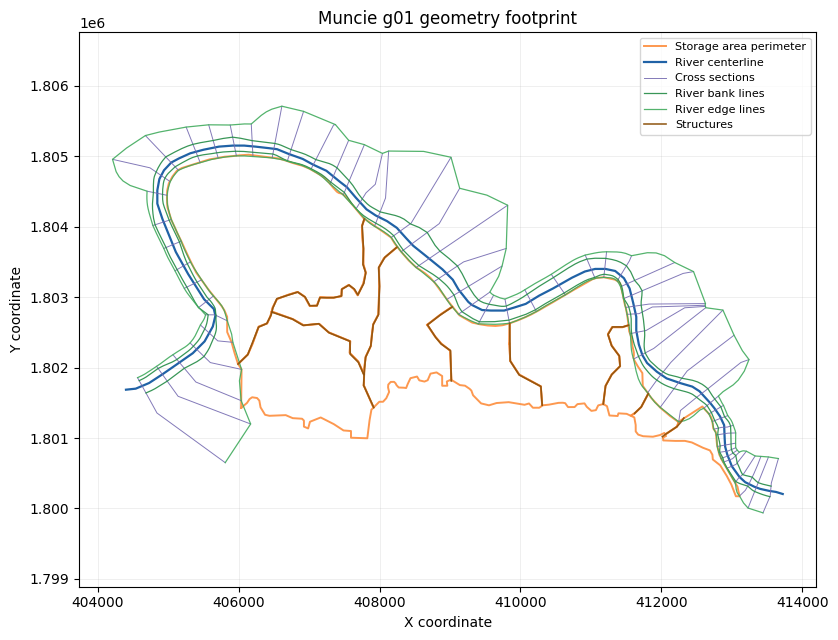

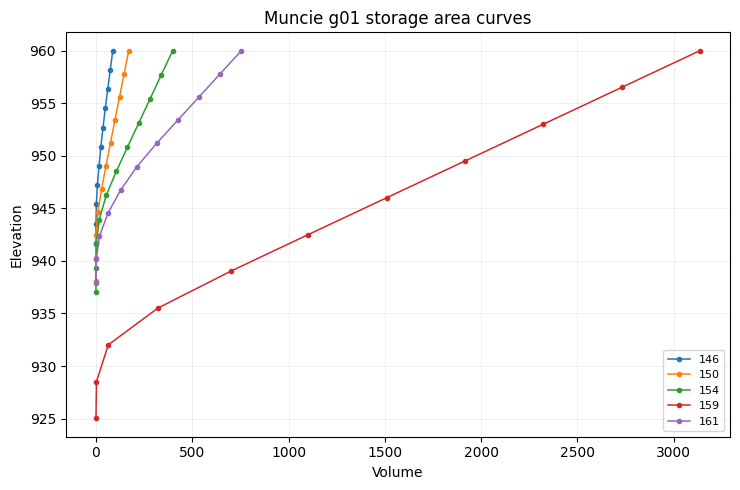

Displayed 3 validation figure(s).


{'label': 'Muncie: storage area elevation-volume curves',
 'project': 'Muncie',
 'geometry_number': '01',
 'plan_number': '02',
 'status': 'passed',
 'passed': True,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm05_muncie_storage_area\\Muncie.p02',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm05_muncie_storage_area\\Muncie.g01',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm05_muncie_storage_area\\Muncie.g01.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm05_muncie_storage_area\\Muncie.p02.hdf',
 '

In [15]:
validate_demo_operation(4)


### Demonstration 6: BaldEagle Multi2D: SA/2D connection from/to


In [16]:
run_demo_operation(DEMO_OPERATIONS[5])


2026-04-29 09:04:38 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:04:38 - ras_commander.RasExamples - INFO - Extracting project 'BaldEagleCrkMulti2D' as 'BaldEagleCrkMulti2D_122_rasmapper_updates_rm06_baldeagle_multi2d_s'


--------------------------------------------------------------------------------
BaldEagle Multi2D: SA/2D connection from/to
Model: BaldEagleCrkMulti2D -> suffix 122_rasmapper_updates_rm06_baldeagle_multi2d_s
Function: RasMapperLayerCommandWorkflow.update_sa2d_connections
Geometry: g12
Plan clone metadata: shortid=RM06_BALDEAGLE_MULTI2D_S, title=RM 06 BaldEagle Multi2D SA 2D co
Args: ('12', 'connection_from_to')
Kwargs: {'timeout': 900}


2026-04-29 09:04:40 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\BaldEagleCrkMulti2D_122_rasmapper_updates_rm06_baldeagle_multi2d_s


2026-04-29 09:04:40 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


...

2026-04-29 09:05:55 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\BaldEagleCrkMulti2D_122_rasmapper_updates_rm06_baldeagle_multi2d_s\BaldEagleDamBrk.p07.hdf


2026-04-29 09:05:55 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\BaldEagleCrkMulti2D_122_rasmapper_updates_rm06_baldeagle_multi2d_s\BaldEagleDamBrk.p07.hdf


2026-04-29 09:05:55 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Compute success: True


WorkflowResult(success=True, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper', 'Start geometry editing', 'Run layer command', 'Wait for command to complete', 'Save geometry'], steps_failed=[], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None, 'Start geometry editing': None, 'Run layer command': None, 'Wait for command to complete': None, 'Save geometry': None}, elapsed_seconds=42.09464406967163, error=None)

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,BaldEagle Multi2D: SA/2D connection from/to,BaldEagleCrkMulti2D,12,07,passed,True,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,True,True,True,True,True,True,True


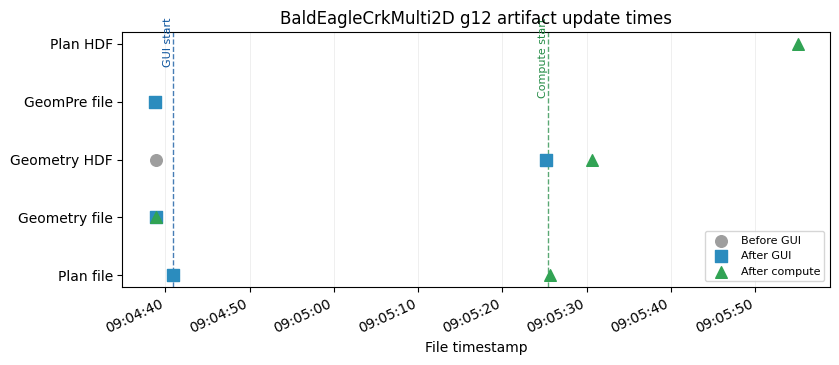

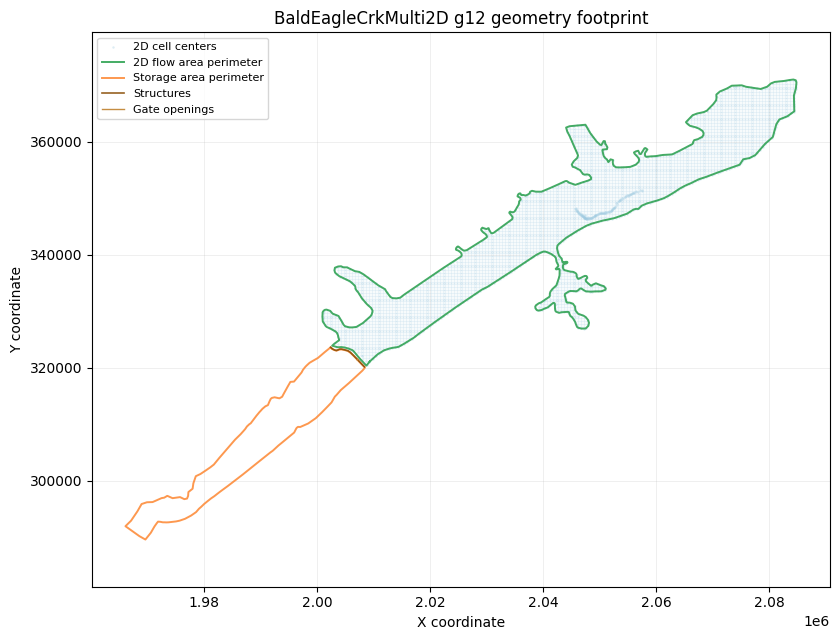

Displayed 2 validation figure(s).


{'label': 'BaldEagle Multi2D: SA/2D connection from/to',
 'project': 'BaldEagleCrkMulti2D',
 'geometry_number': '12',
 'plan_number': '07',
 'status': 'passed',
 'passed': True,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm06_baldeagle_multi2d_s\\BaldEagleDamBrk.p07',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm06_baldeagle_multi2d_s\\BaldEagleDamBrk.g12',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm06_baldeagle_multi2d_s\\BaldEagleDamBrk.g12.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projec

In [17]:
validate_demo_operation(5)


### Demonstration 7: BaldEagle Multi2D: bridge/culvert river stations


In [18]:
run_demo_operation(DEMO_OPERATIONS[6])


2026-04-29 09:05:56 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:05:56 - ras_commander.RasExamples - INFO - Extracting project 'BaldEagleCrkMulti2D' as 'BaldEagleCrkMulti2D_122_rasmapper_updates_rm07_baldeagle_multi2d_b'


--------------------------------------------------------------------------------
BaldEagle Multi2D: bridge/culvert river stations
Model: BaldEagleCrkMulti2D -> suffix 122_rasmapper_updates_rm07_baldeagle_multi2d_b
Function: RasMapperLayerCommandWorkflow.update_structure
Geometry: g03
Plan clone metadata: shortid=RM07_BALDEAGLE_MULTI2D_B, title=RM 07 BaldEagle Multi2D bridge c
Args: ('03', 'bridges_culverts', 'river_stations')
Kwargs: {'timeout': 900}


2026-04-29 09:05:57 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\BaldEagleCrkMulti2D_122_rasmapper_updates_rm07_baldeagle_multi2d_b


2026-04-29 09:05:57 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


...

2026-04-29 09:06:21 - ras_commander.gui.win32_primitives - INFO - Closed window: RAS Mapper


[!] Could not find 'Bridges/Culverts' at depth 1


2026-04-29 09:06:26 - ras_commander.gui.win32_primitives - INFO - Closed window: HEC-RAS 7.0


GUI update success: False
GUI update error: Could not find RASMapper tree node: Single 2D Area with Bridges and Breaklin > Bridges/Culverts


WorkflowResult(success=False, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper'], steps_failed=['Start geometry editing'], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None}, elapsed_seconds=22.84953737258911, error=RuntimeError('Could not find RASMapper tree node: Single 2D Area with Bridges and Breaklin > Bridges/Culverts'))

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,BaldEagle Multi2D: bridge/culvert river stations,BaldEagleCrkMulti2D,03,07,failed,False,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,False,True,True,False,False,False,False


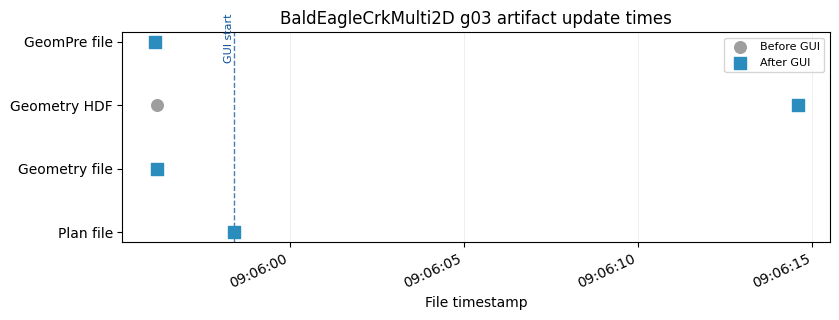

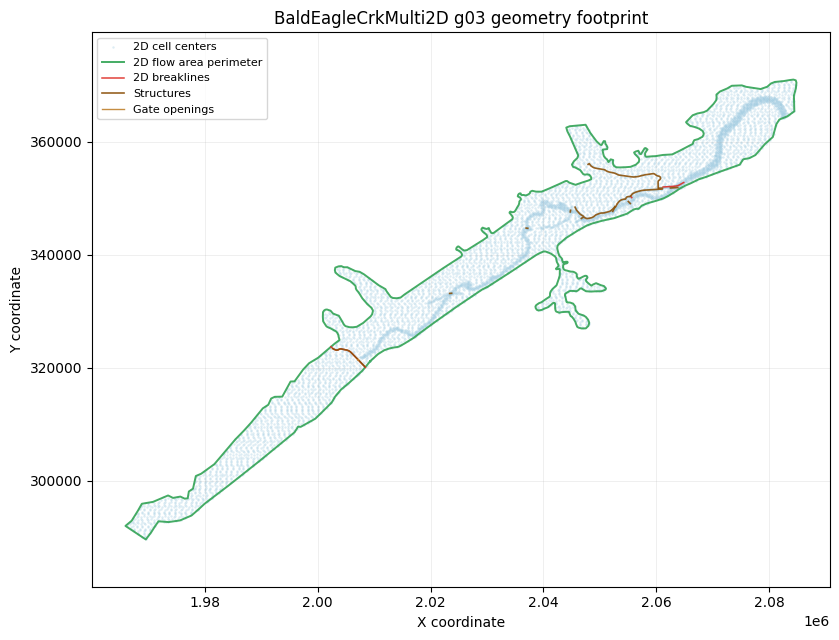

Displayed 2 validation figure(s).


{'label': 'BaldEagle Multi2D: bridge/culvert river stations',
 'project': 'BaldEagleCrkMulti2D',
 'geometry_number': '03',
 'plan_number': '07',
 'status': 'failed',
 'passed': False,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm07_baldeagle_multi2d_b\\BaldEagleDamBrk.p07',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm07_baldeagle_multi2d_b\\BaldEagleDamBrk.g03',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm07_baldeagle_multi2d_b\\BaldEagleDamBrk.g03.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_

In [19]:
validate_demo_operation(6)


### Demonstration 8: BaldEagle Multi2D: bridge/culvert terrain profiles


In [20]:
run_demo_operation(DEMO_OPERATIONS[7])


2026-04-29 09:06:26 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:06:26 - ras_commander.RasExamples - INFO - Extracting project 'BaldEagleCrkMulti2D' as 'BaldEagleCrkMulti2D_122_rasmapper_updates_rm08_baldeagle_multi2d_b'


--------------------------------------------------------------------------------
BaldEagle Multi2D: bridge/culvert terrain profiles
Model: BaldEagleCrkMulti2D -> suffix 122_rasmapper_updates_rm08_baldeagle_multi2d_b
Function: RasMapperLayerCommandWorkflow.update_structure
Geometry: g03
Plan clone metadata: shortid=RM08_BALDEAGLE_MULTI2D_B, title=RM 08 BaldEagle Multi2D bridge c
Args: ('03', 'bridges_culverts', 'terrain')
Kwargs: {'timeout': 900}


2026-04-29 09:06:28 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\BaldEagleCrkMulti2D_122_rasmapper_updates_rm08_baldeagle_multi2d_b


2026-04-29 09:06:28 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


...

2026-04-29 09:06:52 - ras_commander.gui.win32_primitives - INFO - Closed window: RAS Mapper


[!] Could not find 'Bridges/Culverts' at depth 1


2026-04-29 09:06:57 - ras_commander.gui.win32_primitives - INFO - Closed window: HEC-RAS 7.0


GUI update success: False
GUI update error: Could not find RASMapper tree node: Single 2D Area with Bridges and Breaklin > Bridges/Culverts


WorkflowResult(success=False, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper'], steps_failed=['Start geometry editing'], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None}, elapsed_seconds=22.89321994781494, error=RuntimeError('Could not find RASMapper tree node: Single 2D Area with Bridges and Breaklin > Bridges/Culverts'))

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,BaldEagle Multi2D: bridge/culvert terrain prof...,BaldEagleCrkMulti2D,03,07,failed,False,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,False,True,True,False,False,False,False


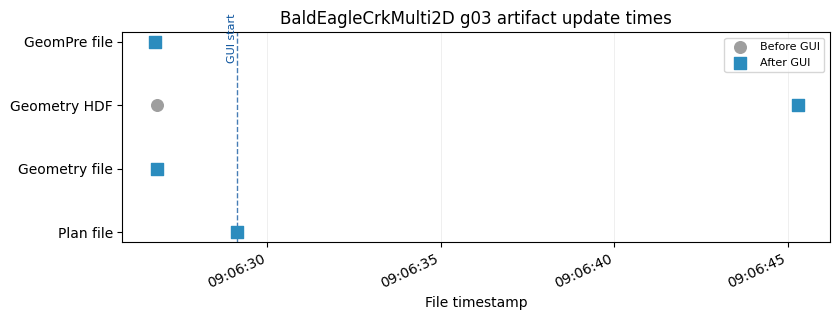

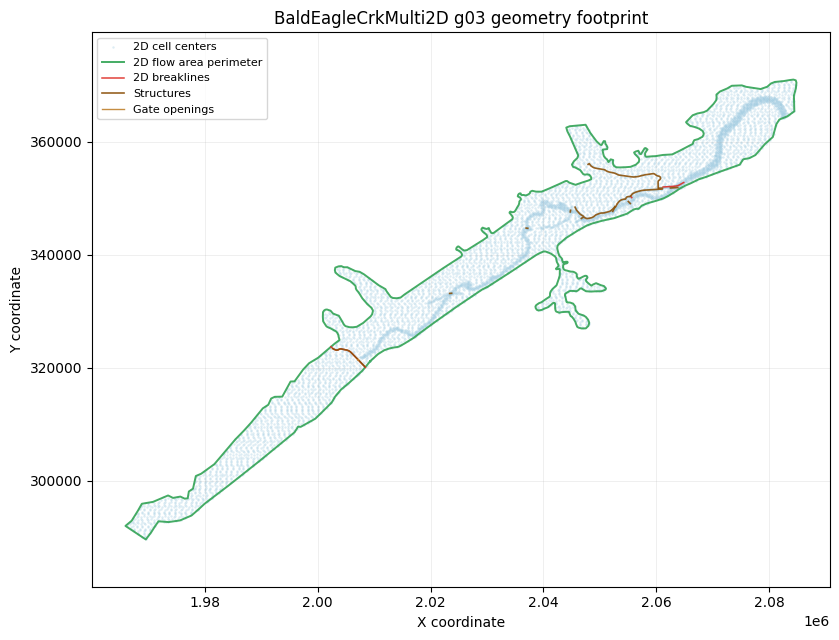

Displayed 2 validation figure(s).


{'label': 'BaldEagle Multi2D: bridge/culvert terrain profiles',
 'project': 'BaldEagleCrkMulti2D',
 'geometry_number': '03',
 'plan_number': '07',
 'status': 'failed',
 'passed': False,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm08_baldeagle_multi2d_b\\BaldEagleDamBrk.p07',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm08_baldeagle_multi2d_b\\BaldEagleDamBrk.g03',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\BaldEagleCrkMulti2D_122_rasmapper_updates_rm08_baldeagle_multi2d_b\\BaldEagleDamBrk.g03.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\exampl

In [21]:
validate_demo_operation(7)


### Demonstration 9: Muncie: lateral structure river stations


In [22]:
run_demo_operation(DEMO_OPERATIONS[8])


2026-04-29 09:06:57 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:06:57 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_122_rasmapper_updates_rm09_muncie_lateral_stru'


--------------------------------------------------------------------------------
Muncie: lateral structure river stations
Model: Muncie -> suffix 122_rasmapper_updates_rm09_muncie_lateral_stru
Function: RasMapperLayerCommandWorkflow.update_structure
Geometry: g01
Plan clone metadata: shortid=RM09_MUNCIE_LATERAL_STRU, title=RM 09 Muncie lateral structure r
Args: ('01', 'lateral', 'river_stations')
Kwargs: {'timeout': 900}


2026-04-29 09:06:57 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm09_muncie_lateral_stru


2026-04-29 09:06:57 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


...

2026-04-29 09:07:43 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm09_muncie_lateral_stru\Muncie.p02.hdf


2026-04-29 09:07:43 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm09_muncie_lateral_stru\Muncie.p02.hdf


2026-04-29 09:07:43 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Compute success: True


WorkflowResult(success=True, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper', 'Start geometry editing', 'Run layer command', 'Wait for command to complete', 'Save geometry'], steps_failed=[], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None, 'Start geometry editing': None, 'Run layer command': None, 'Wait for command to complete': None, 'Save geometry': None}, elapsed_seconds=29.444939851760864, error=None)

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,Muncie: lateral structure river stations,Muncie,01,02,passed,True,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,True,True,True,True,True,True,True


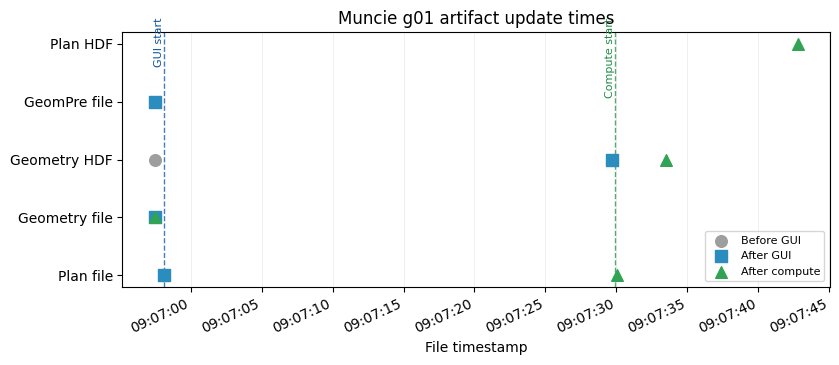

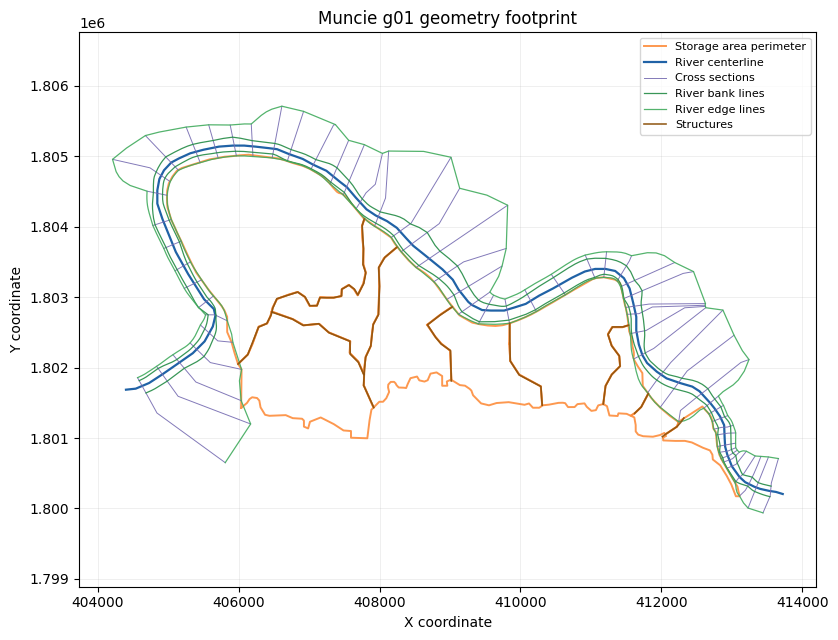

Displayed 2 validation figure(s).


{'label': 'Muncie: lateral structure river stations',
 'project': 'Muncie',
 'geometry_number': '01',
 'plan_number': '02',
 'status': 'passed',
 'passed': True,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm09_muncie_lateral_stru\\Muncie.p02',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm09_muncie_lateral_stru\\Muncie.g01',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm09_muncie_lateral_stru\\Muncie.g01.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm09_muncie_lateral_stru\\Muncie.p02.hdf',
 'plan

In [23]:
validate_demo_operation(8)


### Demonstration 10: Muncie: create edge lines at XS limits


In [24]:
run_demo_operation(DEMO_OPERATIONS[9])


2026-04-29 09:07:43 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:07:43 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_122_rasmapper_updates_rm10_muncie_create_edge_'


--------------------------------------------------------------------------------
Muncie: create edge lines at XS limits
Model: Muncie -> suffix 122_rasmapper_updates_rm10_muncie_create_edge_
Function: RasMapperLayerCommandWorkflow.run_command
Geometry: g01
Plan clone metadata: shortid=RM10_MUNCIE_CREATE_EDGE_, title=RM 10 Muncie create edge lines a
Args: ('Edge Lines', 'edge_lines_compute', '01')
Kwargs: {'timeout': 900}


2026-04-29 09:07:43 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm10_muncie_create_edge_


2026-04-29 09:07:43 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


...

2026-04-29 09:08:28 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm10_muncie_create_edge_\Muncie.p02.hdf


2026-04-29 09:08:28 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm10_muncie_create_edge_\Muncie.p02.hdf


2026-04-29 09:08:28 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Compute success: True


WorkflowResult(success=True, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper', 'Start geometry editing', 'Run layer command', 'Wait for command to complete', 'Save geometry'], steps_failed=[], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None, 'Start geometry editing': None, 'Run layer command': None, 'Wait for command to complete': None, 'Save geometry': None}, elapsed_seconds=28.25086808204651, error=None)

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,Muncie: create edge lines at XS limits,Muncie,01,02,passed,True,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,True,True,True,True,True,True,True


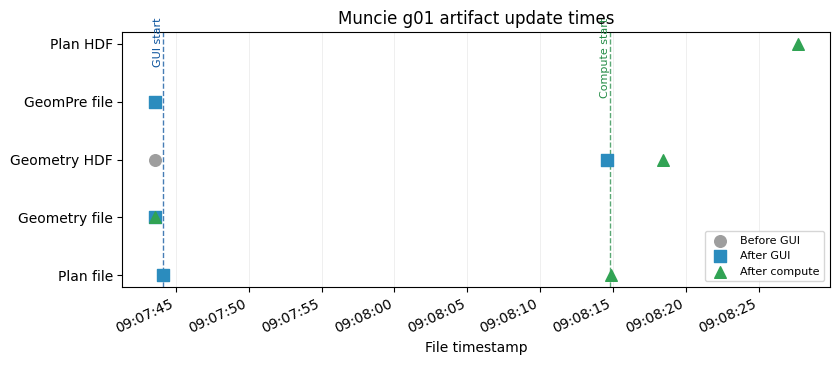

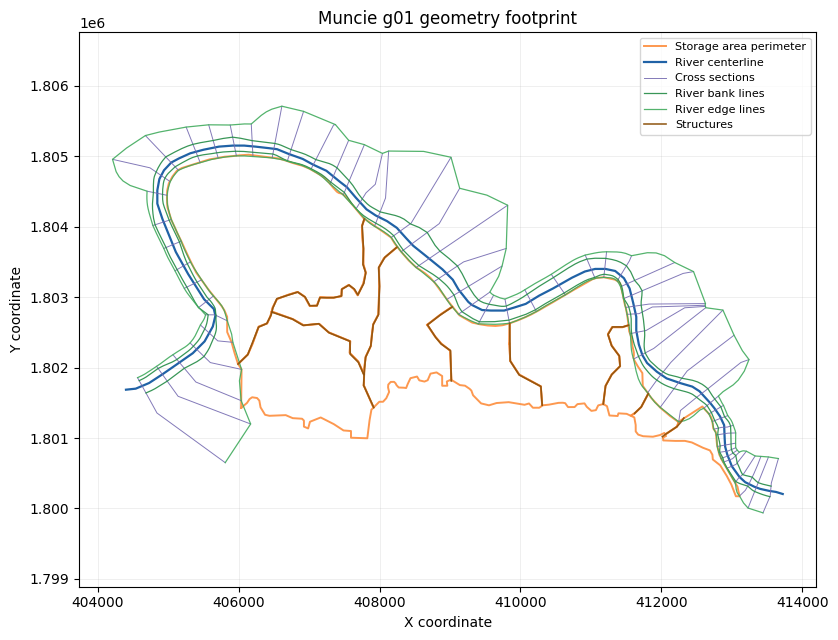

Displayed 2 validation figure(s).


{'label': 'Muncie: create edge lines at XS limits',
 'project': 'Muncie',
 'geometry_number': '01',
 'plan_number': '02',
 'status': 'passed',
 'passed': True,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm10_muncie_create_edge_\\Muncie.p02',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm10_muncie_create_edge_\\Muncie.g01',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm10_muncie_create_edge_\\Muncie.g01.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm10_muncie_create_edge_\\Muncie.p02.hdf',
 'plan_h

In [25]:
validate_demo_operation(9)


### Demonstration 11: HCFCD M3 Clear Creek: update blocked obstructions on XSs


In [26]:
run_demo_operation(DEMO_OPERATIONS[10])


2026-04-29 09:08:28 - ras_commander.sources.county.m3_model - INFO - ----- M3Model Extracting Model -----


2026-04-29 09:08:28 - ras_commander.sources.county.m3_model - INFO - Extracting model 'A' - Clear Creek


2026-04-29 09:08:28 - ras_commander.sources.county.m3_model - INFO - Downloading from: https://files.m3models.org/modellibrary/A_Clear_FEMA_Effective.zip?effectivedate=2022-05-05%2005:00


2026-04-29 09:08:28 - ras_commander.sources.county.m3_model - INFO - Size: 0.03 GB


--------------------------------------------------------------------------------
HCFCD M3 Clear Creek: update blocked obstructions on XSs
Model: HCFCD M3 Clear Creek A120-00-00 -> suffix 122_rasmapper_updates_rm11_hcfcd_m3_clear_cree
Function: RasMapperLayerCommandWorkflow.run_command
Geometry: g01
Plan clone metadata: shortid=RM11_HCFCD_M3_CLEAR_CREE, title=RM 11 HCFCD M3 Clear Creek updat
Args: ('Blocked Obstructions', 'blocked_obstructions_update_on_xss', '01')
Kwargs: {'timeout': 900}


...

2026-04-29 09:08:59 - ras_commander.gui.win32_primitives - INFO - Clicked button: &No


2026-04-29 09:08:59 - ras_commander.gui.hecras_elements - INFO - Dismissed save prompt


2026-04-29 09:08:59 - ras_commander.gui.win32_primitives - INFO - Closed window: HEC-RAS 7.0


GUI update success: True


WorkflowResult(success=True, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper', 'Start geometry editing', 'Run layer command', 'Wait for command to complete', 'Save geometry'], steps_failed=[], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None, 'Start geometry editing': None, 'Run layer command': None, 'Wait for command to complete': None, 'Save geometry': None}, elapsed_seconds=27.962700843811035, error=None)

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_file_read,plan_shortid_updated,plan_title_updated,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_skipped_by_operation
0,HCFCD M3 Clear Creek: update blocked obstructi...,HCFCD M3 Clear Creek A120-00-00,01,01,passed,True,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,True,True,True,True,True,True,True


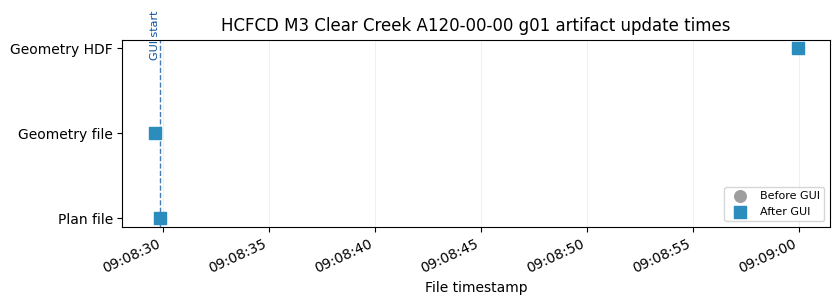

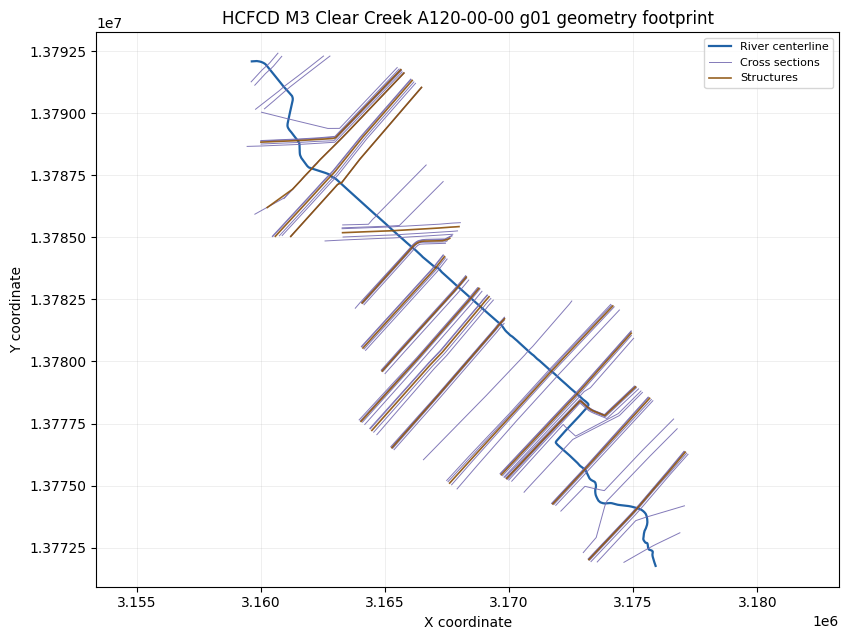

Displayed 2 validation figure(s).


{'label': 'HCFCD M3 Clear Creek: update blocked obstructions on XSs',
 'project': 'HCFCD M3 Clear Creek A120-00-00',
 'geometry_number': '01',
 'plan_number': '01',
 'status': 'passed',
 'passed': True,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\working\\notebook_runs\\example_projects\\A120-00-00_122_rasmapper_updates_rm11_hcfcd_m3_clear_cree\\A120_00_00.p01',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\working\\notebook_runs\\example_projects\\A120-00-00_122_rasmapper_updates_rm11_hcfcd_m3_clear_cree\\A120_00_00.g01',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\working\\notebook_runs\\example_projects\\A120-00-00_122_rasmapper_updates_rm11_hcfcd_m3_clear_cree\\A120_00_00.g01.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\noteb

In [27]:
validate_demo_operation(10)


### Demonstration 12: Muncie: create blocked-obstruction polygons from XS data


In [28]:
run_demo_operation(DEMO_OPERATIONS[11])


2026-04-29 09:09:00 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-29 09:09:00 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_122_rasmapper_updates_rm12_muncie_create_block'


--------------------------------------------------------------------------------
Muncie: create blocked-obstruction polygons from XS data
Model: Muncie -> suffix 122_rasmapper_updates_rm12_muncie_create_block
Function: RasMapperLayerCommandWorkflow.run_command
Geometry: g01
Plan clone metadata: shortid=RM12_MUNCIE_CREATE_BLOCK, title=RM 12 Muncie create blocked obst
Args: ('Blocked Obstructions', 'blocked_obstructions_create_polygons_from_xs', '01')
Kwargs: {'timeout': 900}


2026-04-29 09:09:00 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm12_muncie_create_block


2026-04-29 09:09:00 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


...

2026-04-29 09:09:44 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm12_muncie_create_block\Muncie.p02.hdf


2026-04-29 09:09:44 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: C:\GH\ras-commander\working\notebook_runs\122_full_live_20260429_085928\example_projects\Muncie_122_rasmapper_updates_rm12_muncie_create_block\Muncie.p02.hdf


2026-04-29 09:09:44 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Compute success: True


WorkflowResult(success=True, steps_completed=['Verify HEC-RAS is closed', 'Launch HEC-RAS', 'Open RASMapper', 'Wait for RASMapper', 'Start geometry editing', 'Run layer command', 'Wait for command to complete', 'Save geometry'], steps_failed=[], step_results={'Verify HEC-RAS is closed': None, 'Launch HEC-RAS': None, 'Open RASMapper': None, 'Wait for RASMapper': None, 'Start geometry editing': None, 'Run layer command': None, 'Wait for command to complete': None, 'Save geometry': None}, elapsed_seconds=28.045397520065308, error=None)

,label,project,geometry_number,plan_number,status,passed,plan_path,plan_encoding,geometry_path,geometry_encoding,...,plan_geometry_updated,geometry_preprocessor_enabled,geometry_file_read,gui_update_succeeded,geometry_artifact_updated,geometry_hdf_read,compute_ran,compute_succeeded,result_hdf_read,result_hdf_updated
0,Muncie: create blocked-obstruction polygons fr...,Muncie,01,02,passed,True,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,C:\GH\ras-commander\working\notebook_runs\122_...,utf-8,...,True,True,True,True,True,True,True,True,True,True


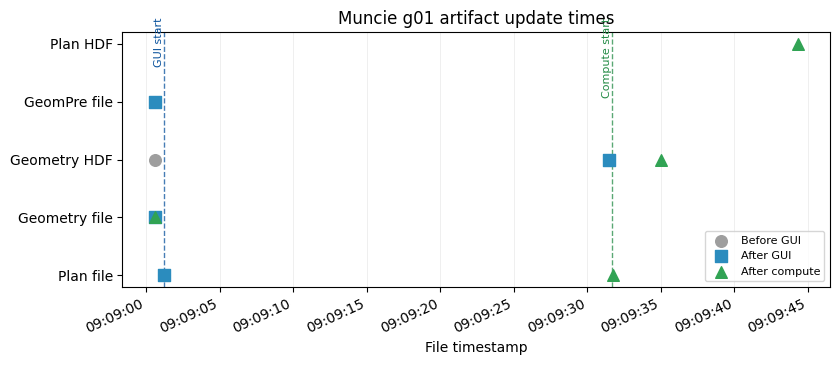

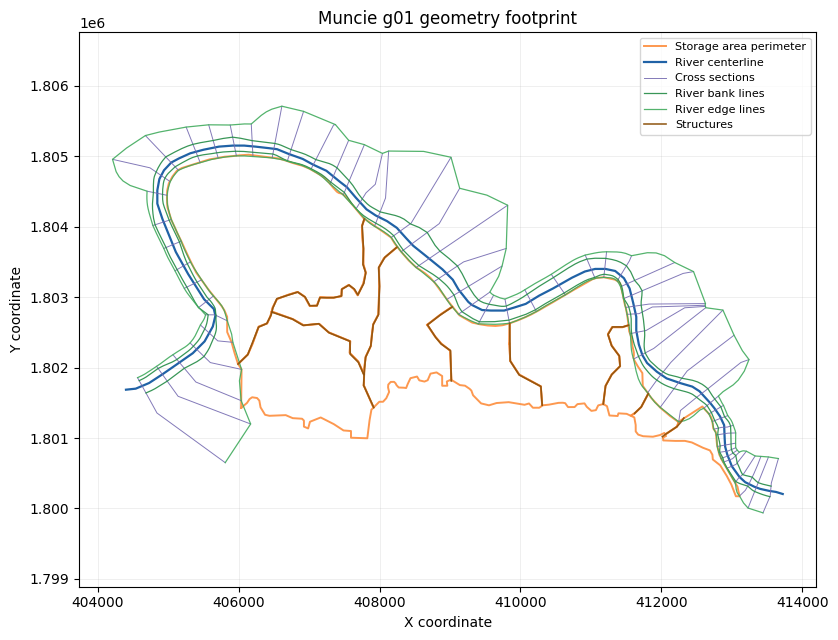

Displayed 2 validation figure(s).


{'label': 'Muncie: create blocked-obstruction polygons from XS data',
 'project': 'Muncie',
 'geometry_number': '01',
 'plan_number': '02',
 'status': 'passed',
 'passed': True,
 'plan_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm12_muncie_create_block\\Muncie.p02',
 'plan_encoding': 'utf-8',
 'geometry_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm12_muncie_create_block\\Muncie.g01',
 'geometry_encoding': 'utf-8',
 'geometry_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm12_muncie_create_block\\Muncie.g01.hdf',
 'geometry_hdf_keys': 'Geometry',
 'plan_hdf_path': 'C:\\GH\\ras-commander\\working\\notebook_runs\\122_full_live_20260429_085928\\example_projects\\Muncie_122_rasmapper_updates_rm12_muncie_create_block\\Muncie.

In [29]:
validate_demo_operation(11)


## Operation Summary


,demo_type,label,project,geometry_number,plan_template,plan_number,plan_shortid,enabled,skip_reason,executed,success,compute_executed,compute_success,validation_status,validation_passed,error
0,1D cross sections,Balde Eagle Creek 1D: all XS attributes except...,Balde Eagle Creek 1D,01,01,03,RM01_BALDE_EAGLE_CREEK_1,True,None,True,True,True,True,passed,True,None
1,2D/pipe model cross sections,Davis pipe model: river stations table,Davis,02,02,01,RM02_DAVIS_PIPE_MODEL_RI,True,None,True,False,False,None,failed,False,Could not find RASMapper tree node: Davis Full...
2,Special pipe/2D model cross sections,New Orleans Metro: elevation profiles from ter...,NewOrleansMetro,02,01,02,RM03_NEW_ORLEANS_METRO_E,True,None,True,False,False,None,failed,False,Could not find RASMapper tree node: 2D Surface...
3,XS interpolation surface,Muncie: compute XS interpolation surface,Muncie,04,04,02,RM04_MUNCIE_COMPUTE_XS_I,True,None,True,True,True,True,passed,True,None
4,Storage area curves,Muncie: storage area elevation-volume curves,Muncie,01,01,02,RM05_MUNCIE_STORAGE_AREA,True,None,True,True,True,True,passed,True,None
5,SA/2D connections,BaldEagle Multi2D: SA/2D connection from/to,BaldEagleCrkMulti2D,12,19,07,RM06_BALDEAGLE_MULTI2D_S,True,None,True,True,True,True,passed,True,None
6,Bridge/culvert properties,BaldEagle Multi2D: bridge/culvert river stations,BaldEagleCrkMulti2D,03,05,07,RM07_BALDEAGLE_MULTI2D_B,True,None,True,False,False,None,failed,False,Could not find RASMapper tree node: Single 2D ...
7,Bridge/culvert terrain profiles,BaldEagle Multi2D: bridge/culvert terrain prof...,BaldEagleCrkMulti2D,03,05,07,RM08_BALDEAGLE_MULTI2D_B,True,None,True,False,False,None,failed,False,Could not find RASMapper tree node: Single 2D ...
8,Lateral structures,Muncie: lateral structure river stations,Muncie,01,01,02,RM09_MUNCIE_LATERAL_STRU,True,None,True,True,True,True,passed,True,None
9,Edge lines,Muncie: create edge lines at XS limits,Muncie,01,01,02,RM10_MUNCIE_CREATE_EDGE_,True,None,True,True,True,True,passed,True,None


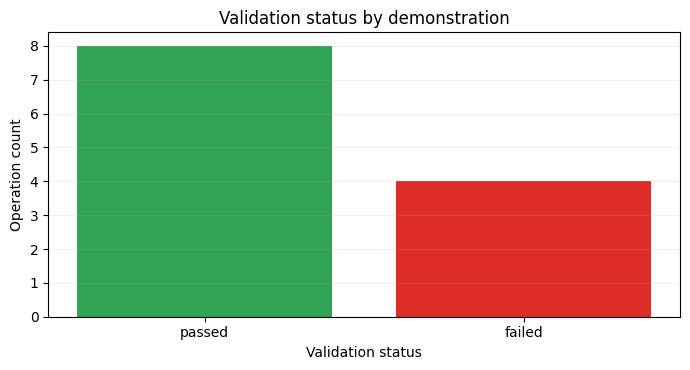

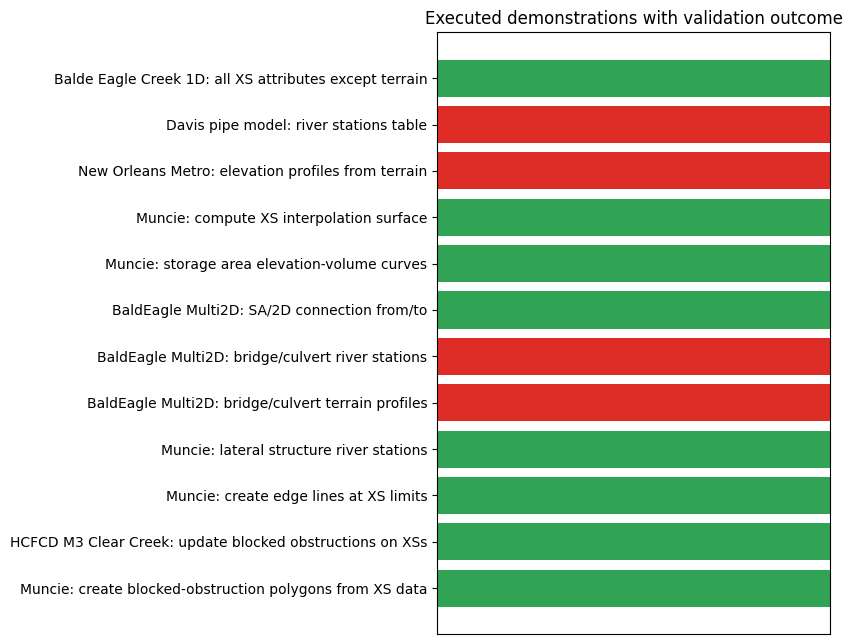

In [30]:
summary = pd.DataFrame([
    {
        "demo_type": item["demo_type"],
        "label": item["label"],
        "project": item["project_label"],
        "geometry_number": item["geometry_number"],
        "plan_template": item["plan_template"],
        "plan_number": item["plan_number"],
        "plan_shortid": item["plan_shortid"],
        "enabled": item["enabled"],
        "skip_reason": item["skip_reason"],
        "executed": item["executed"],
        "success": item["success"],
        "compute_executed": item["compute_executed"],
        "compute_success": item["compute_success"],
        "validation_status": item["validation_status"],
        "validation_passed": item["validation_passed"],
        "error": item["error"],
    }
    for item in operation_log
])
display(summary)

_ = display_summary_figures(summary)


## Notes

- The notebook deliberately uses isolated project copies so repeated validation does not mutate the source examples.
- `NewOrleansMetro` is a special downloadable example project. The project file contains Windows-1252 characters, so `RasPrj` needs fallback encoding support when reading project entries.
- The HCFCD M3 example uses the local `examples/m3_models/Clear Creek/HEC-RAS/A120-00-00` project when present. If that folder is missing, the helper falls back to `M3Model.extract_model("A")` and extracts `A120-00-00.zip`.
- Individual feature-level operations remain configurable through the optional node variables; the main matrix focuses on one all-feature demonstration per geometry/update type.
